# Laboratorio 7 — NLP end-to-end y Embeddings
**CC3092 Deep Learning y Sistemas Inteligentes**

Pipeline completo: texto crudo → tokens → IDs → embeddings (SGNS propio en PyTorch, Word2Vec de gensim y GloVe)
→ evaluación intrínseca (analogías, similitud) → clasificación de AG News.

Todos los artefactos pesados (corpus tokenizado, modelos entrenados, logs) se guardan en `data/`, `models/` y
`results/` para que el notebook pueda re-ejecutarse sin repetir el entrenamiento.

In [1]:
import os, re, json, time, math, html, random, gc, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import spearmanr
from datasets import load_dataset
import gensim.downloader as api
from gensim.test.utils import datapath

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROOT = Path(".").resolve()
DATA, MODELS, RESULTS, FIGS = ROOT / "data", ROOT / "models", ROOT / "results", ROOT / "figures"
for p in (DATA, MODELS, RESULTS, FIGS):
    p.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIGS / f"{name}.pdf", bbox_inches="tight")
    plt.savefig(FIGS / f"{name}.png", bbox_inches="tight", dpi=150)
    plt.show()

def save_json(obj, name):
    with open(RESULTS / name, "w") as f:
        json.dump(obj, f, indent=2, default=float)

HW = {
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "cpu_threads": os.cpu_count(),
    "torch": torch.__version__,
}
print(HW)

{'gpu': 'NVIDIA GeForce RTX 3070 Laptop GPU', 'cpu_threads': 8, 'torch': '2.14.1+cu130'}


## 1. Datos
Corpus crudo (WikiText-103), dataset de clasificación (AG News), modelo preentrenado (GloVe 100d) y benchmarks.

In [2]:
corpus = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
news = load_dataset("fancyzhx/ag_news")
glove = api.load("glove-wiki-gigaword-100")

ANALOGIAS = datapath("questions-words.txt")   # 19,544 analogías, 14 categorías
WORDSIM = datapath("wordsim353.tsv")
SIMLEX = datapath("simlex999.txt")
print(corpus)
print(news)
print("GloVe:", len(glove.index_to_key), "palabras, dim", glove.vector_size)

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 1801350
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
GloVe: 400000 palabras, dim 100


## 2. Exploración y preprocesamiento del texto
### 2.1 Estructura del corpus
En WikiText cada artículo empieza con una línea de título `" = Título = "` (un solo `=`); las secciones usan
`" = = Sección = = "`. Las líneas vacías separan párrafos. Contamos artículos, líneas y tokens (por espacios,
es decir, la tokenización original del dataset, que separa la puntuación).

In [3]:
TITLE_RE = re.compile(r"^ = [^=].* = \n$")
HEAD_RE = re.compile(r"^ (= )+.*( =)+ \n$")

def corpus_stats(split):
    texts = corpus[split]["text"]
    n_art = n_lines = n_nonempty = n_head = n_tok = 0
    for t in texts:
        n_lines += 1
        if not t.strip():
            continue
        n_nonempty += 1
        if TITLE_RE.match(t):
            n_art += 1
        elif HEAD_RE.match(t):
            n_head += 1
        n_tok += len(t.split())
    return dict(split=split, articulos=n_art, lineas=n_lines, lineas_no_vacias=n_nonempty,
                encabezados=n_head, tokens_espacio=n_tok)

stats = pd.DataFrame([corpus_stats(s) for s in ("train", "validation", "test")])
stats

,split,articulos,lineas,lineas_no_vacias,encabezados,tokens_espacio
0,train,29444,1801350,1165029,275630,101425671
1,validation,60,3760,2461,560,213886
2,test,62,4358,2891,644,241211


### 2.2 Normalización y tokenizador propio
Decisiones (todas pensadas para ser **consistentes con el vocabulario de GloVe 6B**, que es *uncased* y fue
tokenizado con el tokenizador de Stanford, estilo Penn Treebank):

1. **Minúsculas**: GloVe 6B no distingue mayúsculas; si no bajamos a minúsculas, `Paris`/`paris` serían palabras
   distintas y las analogías (que se evalúan en minúsculas) perderían cobertura.
2. **Artefactos de WikiText**: `@-@`, `@,@`, `@.@` se reconstruyen (`well @-@ known → well-known`,
   `1 @,@ 000 → 1,000`, `1 @.@ 5 → 1.5`), porque GloVe tiene esos tokens compuestos.
3. **Contracciones estilo PTB**: `didn't`/`didn 't → did n't`, `game's → game 's`, `can't → ca n't`
   (GloVe contiene `n't`, `'s`, `ca`, `wo`).
4. **Guiones**: se conservan las palabras compuestas (`state-of-the-art`, `spider-man`) como un token.
5. **Abreviaturas**: siglas con puntos (`u.s.`, `e.g.`) y títulos/meses abreviados (`dr.`, `mr.`, `jan.`) se
   mantienen como un token, igual que en GloVe.
6. **Números**: se conservan como dígitos (`2010`, `1,000`, `1.5`), sin reemplazarlos por un token `<num>`,
   porque GloVe los mantiene y las comparaciones usan su vocabulario.
7. **Puntuación**: se elimina. No participa en ningún benchmark y ocuparía posiciones de la ventana de contexto
   (en GloVe `,` y `.` son el 2º y 3er token más frecuente).
8. **Tokens especiales**: para los embeddings no se usa `<unk>` dentro del flujo de entrenamiento — igual que
   Word2Vec, las palabras bajo `min_count` se *eliminan* antes de formar ventanas. En clasificación se usan
   `<pad>` (índice 0, `padding_idx`) y las palabras fuera de vocabulario se descartan.

Lo que **debe** coincidir con GloVe para una comparación justa: minúsculas, contracciones separadas igual,
compuestos con guion y números en el mismo formato. Si no, una palabra que existe en ambos modelos tendría una
forma distinta y las preguntas de analogía/similitud se evaluarían sobre conjuntos diferentes.

In [4]:
ABBREV = r"(?:mr|mrs|ms|dr|st|jr|sr|inc|corp|ltd|vs|prof|gen|gov|sen|lt|col|sgt|capt|mt|jan|feb|aug|sept|oct|nov|dec)\."
TOKEN_RE = re.compile(
    r"(?:[a-z]\.){2,}"                 # siglas: u.s., e.g., a.m.
    rf"|\b{ABBREV}"                    # abreviaturas con punto: dr., mr., jan.
    r"|\d+(?:[.,:]\d+)+"               # números con separador: 1,000  3.14  10:30
    r"|n't|'(?:s|re|ve|ll|d|m)\b"      # clíticos estilo PTB
    r"|[^\W_]+(?:['\-][^\W_]+)*"       # palabras (con guiones/apóstrofos internos: state-of-the-art, o'brien)
)
WIKI_FIX = [(" @-@ ", "-"), (" @,@ ", ","), (" @.@ ", ".")]

def normalize(text):
    """Normalización compartida por WikiText y AG News."""
    t = text.lower()
    for a, b in WIKI_FIX:                                   # artefactos de WikiText
        t = t.replace(a, b)
    t = re.sub(r"#(\d+);", lambda m: chr(int(m.group(1))), t)  # entidades rotas de AG News (#39; -> ')
    t = html.unescape(t).replace("\\", " ")
    t = re.sub(r"<[^>]+>", " ", t)                          # etiquetas html sueltas
    t = t.replace("’", "'").replace("`", "'")
    t = re.sub(r"(\w)n ?'t\b", r"\1 n't", t)               # didn't / didn 't -> did n't
    t = re.sub(r"(\w) ?'(s|re|ve|ll|d|m)\b", r"\1 '\2", t)  # game's / game 's -> game 's
    t = re.sub(r"\b([od]) '(?=[a-z])", r"\1'", t)           # o 'brien -> o'brien
    return t

def tokenize(text):
    """Tokenizador por palabra propio: normaliza y extrae tokens con una sola regex."""
    return TOKEN_RE.findall(normalize(text))

print(tokenize(" The game 's battle system , the BliTZ system , is a role @-@ playing game ; it didn 't sell 1 @,@ 000 copies . "))
print(tokenize("Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics"))

['the', 'game', "'s", 'battle', 'system', 'the', 'blitz', 'system', 'is', 'a', 'role-playing', 'game', 'it', 'did', "n't", 'sell', '1,000', 'copies']
['wall', 'st.', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short-sellers', 'wall', 'street', "'s", 'dwindling', 'band', 'of', 'ultra-cynics']


### 2.3 Comparación con tokenizadores de librería (NLTK y spaCy)

In [5]:
import nltk, spacy
from nltk.tokenize import word_tokenize
nltk.download("punkt_tab", quiet=True)
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "ner", "lemmatizer", "attribute_ruler"])

EJEMPLOS = [
    "I don't think they'll arrive before 5 p.m.",
    "She can't believe it's already 2024!",
    "The state-of-the-art model costs $1,000.50 in the U.S.",
    "Dr. Smith and Mr. O'Brien met at St. Paul's.",
    "We'll see the well-known New York-based company e.g. tomorrow.",
    "He said: \"Rock'n'roll isn't dead\" -- or is it?",
    "The co-founder's e-mail was jsmith@example.com.",
    "Temperatures rose 3.5% between Jan. 1 and Feb. 28.",
    "You're right, I'd've done it differently.",
    "The 1990s were the decade of the X-Files and Spider-Man.",
    "Prices fell 10-15 percent (approx.) in the U.K.'s markets.",
    "It's a self-driving car; won't it crash?",
]

def lib_nltk(s): return [t for t in word_tokenize(s.lower()) if re.search(r"\w", t)]
def lib_spacy(s): return [t.text for t in nlp(s.lower()) if re.search(r"\w", t.text)]

rows = []
for s in EJEMPLOS:
    a, b, c = tokenize(s), lib_nltk(s), lib_spacy(s)
    rows.append(dict(oracion=s, propio=" | ".join(a), nltk=" | ".join(b), spacy=" | ".join(c),
                     igual_nltk=a == b, igual_spacy=a == c))
tok_cmp = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 120)
for r in rows:
    print(f"\n{r['oracion']}\n  propio: {r['propio']}\n  nltk  : {r['nltk']}\n  spacy : {r['spacy']}")
tok_cmp[["oracion", "igual_nltk", "igual_spacy"]]

/home/anthony/Repositorios/Lab7-DL/.venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/anthony/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):



I don't think they'll arrive before 5 p.m.
  propio: i | do | n't | think | they | 'll | arrive | before | 5 | p.m.
  nltk  : i | do | n't | think | they | 'll | arrive | before | 5 | p.m
  spacy : i | do | n't | think | they | 'll | arrive | before | 5 | p.m.

She can't believe it's already 2024!
  propio: she | ca | n't | believe | it | 's | already | 2024
  nltk  : she | ca | n't | believe | it | 's | already | 2024
  spacy : she | ca | n't | believe | it | 's | already | 2024

The state-of-the-art model costs $1,000.50 in the U.S.
  propio: the | state-of-the-art | model | costs | 1,000.50 | in | the | u.s.
  nltk  : the | state-of-the-art | model | costs | 1,000.50 | in | the | u.s
  spacy : the | state | of | the | art | model | costs | 1,000.50 | in | the | u.s

Dr. Smith and Mr. O'Brien met at St. Paul's.
  propio: dr. | smith | and | mr. | o'brien | met | at | st. | paul | 's
  nltk  : dr. | smith | and | mr. | o'brien | met | at | st. | paul | 's
  spacy : dr | smith | and |

,oracion,igual_nltk,igual_spacy
0,I don't think they'll arrive before 5 p.m.,False,True
1,She can't believe it's already 2024!,True,True
2,"The state-of-the-art model costs $1,000.50 in the U.S.",False,False
3,Dr. Smith and Mr. O'Brien met at St. Paul's.,True,False
4,We'll see the well-known New York-based company e.g. tomorrow.,False,False
5,"He said: ""Rock'n'roll isn't dead"" -- or is it?",True,True
6,The co-founder's e-mail was jsmith@example.com.,False,False
7,Temperatures rose 3.5% between Jan. 1 and Feb. 28.,True,False
8,"You're right, I'd've done it differently.",False,True
9,The 1990s were the decade of the X-Files and Spider-Man.,True,False


Para comparar sólo la segmentación, a las salidas de NLTK/spaCy se les quitó la puntuación pura (como hace el
nuestro). Diferencias típicas: **contracciones** (`they'll`, `I'd've`: spaCy y NLTK coinciden con PTB; el nuestro
también separa `'ll`/`'d`, pero `'ve` tras otro clítico queda distinto), **guiones** (NLTK conserva `10-15`,
spaCy parte `york-based` según reglas de infijos), **abreviaturas** (`p.m.`, `approx.`, `u.k.'s`) y
**correos/porcentajes**. Nuestro tokenizador prioriza coincidir con las formas presentes en GloVe.

### 2.4 Tokenización de todo el corpus → IDs
Se tokeniza el split de entrenamiento completo (≈101 M tokens por espacios). Cada línea no vacía (párrafo) se
trata como una "oración": las ventanas de contexto no cruzan párrafos. Las líneas de título/sección se omiten.
Se guarda: arreglo plano de IDs (`int32`), desplazamientos de líneas y el inicio de cada artículo.

In [6]:
CORPUS_CACHE = DATA / "wiki_tokens.npz"

if not CORPUS_CACHE.exists():
    t0 = time.time()
    word2tmp, tmp_counts = {}, []
    ids_chunks, line_lens, art_line_start = [], [], []
    n_lines = 0
    for t in corpus["train"]["text"]:
        if not t.strip():
            continue
        if TITLE_RE.match(t):
            art_line_start.append(n_lines)
            continue
        if HEAD_RE.match(t):
            continue
        toks = tokenize(t)
        if not toks:
            continue
        ids = []
        for w in toks:
            i = word2tmp.get(w)
            if i is None:
                i = word2tmp[w] = len(tmp_counts); tmp_counts.append(0)
            tmp_counts[i] += 1
            ids.append(i)
        ids_chunks.append(np.asarray(ids, dtype=np.int32))
        line_lens.append(len(ids))
        n_lines += 1
    flat = np.concatenate(ids_chunks)
    tmp_words = np.array(list(word2tmp.keys()), dtype=object)
    np.savez(CORPUS_CACHE, ids=flat, line_lens=np.asarray(line_lens, np.int64),
             art_line_start=np.asarray(art_line_start, np.int64),
             words=tmp_words, counts=np.asarray(tmp_counts, np.int64))
    print(f"tokenizado en {time.time()-t0:.0f}s")

z = np.load(CORPUS_CACHE, allow_pickle=True)
FLAT, LINE_LENS, ART_LINE_START = z["ids"], z["line_lens"], z["art_line_start"]
TMP_WORDS, TMP_COUNTS = z["words"], z["counts"]
LINE_OFF = np.concatenate([[0], np.cumsum(LINE_LENS)])
print(f"tokens normalizados: {len(FLAT):,} | párrafos: {len(LINE_LENS):,} | artículos: {len(ART_LINE_START):,} | tipos: {len(TMP_WORDS):,}")

tokens normalizados: 84,593,278 | párrafos: 858,019 | artículos: 29,444 | tipos: 717,430


### 2.5 Ley de Zipf
Frecuencia contra rango en escala log-log sobre el corpus completo. Ajustamos una recta en el rango 10–10,000
(la región "lineal") para estimar el exponente $s$ de $f(r) \propto r^{-s}$.

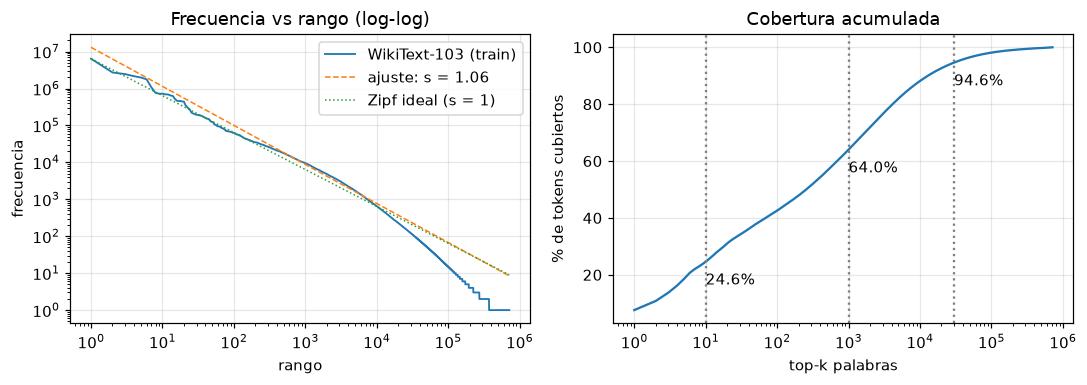

{
 "exponente_s": 1.056879365880257,
 "total_tokens": 84593278,
 "tipos": 717430,
 "cobertura_top10": 0.24611089074949904,
 "cobertura_top1000": 0.6400906464459268,
 "cobertura_top30000": 0.9462935577458058,
 "top10": [
  "the",
  "of",
  "and",
  "in",
  "to",
  "a",
  "was",
  "on",
  "'s",
  "as"
 ]
}


In [7]:
order = np.argsort(-TMP_COUNTS, kind="stable")
freqs = TMP_COUNTS[order]
ranks = np.arange(1, len(freqs) + 1)
total_tokens = freqs.sum()
cum = np.cumsum(freqs) / total_tokens

sel = (ranks >= 10) & (ranks <= 10_000)
slope, intercept = np.polyfit(np.log10(ranks[sel]), np.log10(freqs[sel]), 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].loglog(ranks, freqs, lw=1.2, label="WikiText-103 (train)")
ax[0].loglog(ranks, 10 ** intercept * ranks ** slope, "--", lw=1, label=f"ajuste: s = {-slope:.2f}")
ax[0].loglog(ranks, freqs[0] / ranks, ":", lw=1, label="Zipf ideal (s = 1)")
ax[0].set(xlabel="rango", ylabel="frecuencia", title="Frecuencia vs rango (log-log)"); ax[0].legend()
ax[1].semilogx(ranks, cum * 100)
for k in (10, 1_000, 30_000):
    ax[1].axvline(k, ls=":", c="gray"); ax[1].annotate(f"{cum[k-1]*100:.1f}%", (k, cum[k-1]*100 - 8))
ax[1].set(xlabel="top-k palabras", ylabel="% de tokens cubiertos", title="Cobertura acumulada")
savefig("zipf")

zipf = {"exponente_s": float(-slope), "total_tokens": int(total_tokens), "tipos": int(len(freqs)),
        **{f"cobertura_top{k}": float(cum[k - 1]) for k in (10, 1_000, 30_000)},
        "top10": [TMP_WORDS[i] for i in order[:10]]}
print(json.dumps(zipf, indent=1))

### 2.6 Subconjunto de entrenamiento y vocabulario (`min_count`)
Por cómputo (RTX 3070 Laptop, 8 GB) usamos los primeros artículos de WikiText-103 hasta acumular ≈30 M tokens
(mínimo exigido: 20 M). Es **el mismo** subconjunto para el SGNS propio y para gensim. Los subconjuntos de 25 %
y 50 % (experimento de tamaño de corpus) son prefijos de este, cortados en frontera de artículo.

In [8]:
SUBSET_TOKENS = 30_000_000

def subset_by_tokens(n_tokens):
    """Devuelve (ids, line_lens) de los primeros artículos completos hasta n_tokens."""
    art_tok_start = LINE_OFF[ART_LINE_START]
    a = np.searchsorted(art_tok_start, n_tokens)            # primer artículo que empieza después del límite
    end_line = ART_LINE_START[a] if a < len(ART_LINE_START) else len(LINE_LENS)
    return FLAT[:LINE_OFF[end_line]], LINE_LENS[:end_line]

SUB_IDS, SUB_LENS = subset_by_tokens(SUBSET_TOKENS)
sub_counts = np.bincount(SUB_IDS, minlength=len(TMP_WORDS))
print(f"subconjunto: {len(SUB_IDS):,} tokens, {len(SUB_LENS):,} párrafos, {int((sub_counts>0).sum()):,} tipos")

rows = []
for mc in (1, 2, 3, 5, 10, 20, 50):
    keep = sub_counts >= mc
    rows.append(dict(min_count=mc, vocab=int(keep.sum()),
                     pct_tokens_desconocidos=100 * (1 - sub_counts[keep].sum() / sub_counts.sum())))
vocab_tbl = pd.DataFrame(rows)
vocab_tbl

subconjunto: 30,000,534 tokens, 306,297 párrafos, 392,765 tipos


,min_count,vocab,pct_tokens_desconocidos
0,1,392765,0.000000
1,2,206965,0.619322
2,3,153008,0.979029
3,5,109700,1.467754
4,10,72652,2.275926
5,20,48370,3.376517
6,50,27810,5.505202


Elegimos `min_count = 5` (valor por defecto de Word2Vec): reduce el vocabulario a una fracción de los tipos con
una pérdida pequeña de tokens, y elimina en su mayoría errores tipográficos y nombres propios raros cuyos vectores
serían de mala calidad (pocas actualizaciones).

In [9]:
class Vocab:
    """Vocabulario ordenado por frecuencia (id 0 = palabra más frecuente)."""
    def __init__(self, ids, min_count):
        counts = np.bincount(ids, minlength=len(TMP_WORDS))
        tmp_keep = np.where(counts >= min_count)[0]
        tmp_keep = tmp_keep[np.argsort(-counts[tmp_keep], kind="stable")]
        self.itos = [str(TMP_WORDS[i]) for i in tmp_keep]
        self.stoi = {w: i for i, w in enumerate(self.itos)}
        self.counts = counts[tmp_keep].astype(np.int64)
        self.tmp2id = np.full(len(TMP_WORDS), -1, np.int64); self.tmp2id[tmp_keep] = np.arange(len(tmp_keep))
        self.min_count = min_count
    def __len__(self): return len(self.itos)
    def encode(self, ids, lens):
        """Pasa de IDs temporales a IDs del vocabulario, eliminando las palabras fuera de vocabulario."""
        new = self.tmp2id[ids]
        keep = new >= 0
        line_id = np.repeat(np.arange(len(lens)), lens)
        new_lens = np.bincount(line_id[keep], minlength=len(lens))
        return new[keep], new_lens

MIN_COUNT = 5
vocab = Vocab(SUB_IDS, MIN_COUNT)
TRAIN_IDS, TRAIN_LENS = vocab.encode(SUB_IDS, SUB_LENS)
print(f"vocabulario: {len(vocab):,} | tokens tras eliminar OOV: {len(TRAIN_IDS):,}")

vocabulario: 109,700 | tokens tras eliminar OOV: 29,560,200


### 2.7 Submuestreo de palabras frecuentes
Usamos la fórmula de la implementación en C de Word2Vec (la misma de gensim), con $f(w)$ la frecuencia relativa y
umbral $t$:
$$P_{\text{keep}}(w) = \left(\sqrt{\tfrac{f(w)}{t}} + 1\right)\frac{t}{f(w)}$$
(el artículo original propone $P_{\text{discard}} = 1-\sqrt{t/f}$, muy parecida). Calculamos la probabilidad
esperada y la verificamos empíricamente muestreando una epoch.

In [10]:
def keep_prob(counts, t):
    f = counts / counts.sum()
    return np.minimum(1.0, (np.sqrt(f / t) + 1) * t / f)

def subsample(ids, lens, pkeep, rng):
    """Una pasada de submuestreo: devuelve los ids conservados y las nuevas longitudes de párrafo."""
    keep = rng.random(len(ids)) < pkeep[ids]
    line_id = np.repeat(np.arange(len(lens)), lens)
    return ids[keep], np.bincount(line_id[keep], minlength=len(lens))

rng = np.random.default_rng(SEED)
rows = []
for t in (1e-3, 1e-4, 1e-5):
    pk = keep_prob(vocab.counts, t)
    kept_ids, _ = subsample(TRAIN_IDS, TRAIN_LENS, pk, rng)
    kept_counts = np.bincount(kept_ids, minlength=len(vocab))
    for w in ("the", "of", "and"):
        i = vocab.stoi[w]
        rows.append(dict(t=t, palabra=w, frec_rel=vocab.counts[i] / vocab.counts.sum(),
                         pct_descartado_esperado=100 * (1 - pk[i]),
                         pct_descartado_empirico=100 * (1 - kept_counts[i] / vocab.counts[i])))
    rows.append(dict(t=t, palabra="(corpus)", frec_rel=1.0, pct_descartado_esperado=np.nan,
                     pct_descartado_empirico=100 * (1 - len(kept_ids) / len(TRAIN_IDS))))
subs_tbl = pd.DataFrame(rows)
subs_tbl

,t,palabra,frec_rel,pct_descartado_esperado,pct_descartado_empirico
0,0.00100,the,0.076877,87.294089,87.284644
1,0.00100,of,0.032818,79.496867,79.531740
2,0.00100,and,0.029578,78.231857,78.207378
3,0.00100,(corpus),1.000000,NaN,22.581491
4,0.00010,the,0.076877,96.263301,96.268051
5,0.00010,of,0.032818,94.175213,94.184117
6,0.00010,and,0.029578,93.847354,93.806558
7,0.00010,(corpus),1.000000,NaN,39.869409
8,0.00001,the,0.076877,98.846478,98.848323
9,0.00001,of,0.032818,98.223928,98.219363


El submuestreo ayuda porque (i) las palabras muy frecuentes aportan poca información (ver "the" junto a "france"
no dice casi nada de "france"), (ii) reduce mucho el número de pares → epochs más rápidas, y (iii) al eliminar
tokens antes de formar ventanas, éstas abarcan efectivamente más palabras de contenido. Empíricamente mejora los
vectores de palabras raras (Mikolov et al., 2013).

### 2.8 Pares (centro, contexto) para skip-gram
Ventana $W=5$. Contamos los pares exactos con ventana fija y los de la ventana dinámica de Word2Vec (para cada
centro se muestrea $b\sim U\{1..W\}$ y se usan sólo los contextos a distancia $\le b$), antes y después del
submuestreo ($t=10^{-4}$). Las ventanas no cruzan párrafos.

In [11]:
def count_pairs_fixed(lens, W):
    """Pares exactos con ventana fija: sum_i min(i,W) + min(n-1-i,W) por párrafo de longitud n."""
    lens = np.asarray(lens, np.int64)
    total = 0
    for d in range(1, W + 1):
        total += 2 * np.clip(lens - d, 0, None).sum()
    return int(total)

def count_pairs_dynamic(lens, W, rng):
    """Pares con ventana dinámica (b ~ U{1..W} por centro), contados exactamente para una muestra."""
    lens = np.asarray(lens, np.int64)
    n = int(lens.sum())
    pos = np.arange(n) - np.repeat(np.concatenate([[0], np.cumsum(lens)[:-1]]), lens)  # posición en párrafo
    plen = np.repeat(lens, lens)
    b = rng.integers(1, W + 1, size=n)
    left = np.minimum(pos, b); right = np.minimum(plen - 1 - pos, b)
    return int((left + right).sum())

W = 5
pk = keep_prob(vocab.counts, 1e-4)
sub_ids_, sub_lens_ = subsample(TRAIN_IDS, TRAIN_LENS, pk, rng)
pairs_tbl = pd.DataFrame([
    dict(etapa="sin submuestreo", tokens=len(TRAIN_IDS), pares_ventana_fija=count_pairs_fixed(TRAIN_LENS, W),
         pares_ventana_dinamica=count_pairs_dynamic(TRAIN_LENS, W, rng)),
    dict(etapa="con submuestreo t=1e-4", tokens=len(sub_ids_), pares_ventana_fija=count_pairs_fixed(sub_lens_, W),
         pares_ventana_dinamica=count_pairs_dynamic(sub_lens_, W, rng)),
])
pairs_tbl

,etapa,tokens,pares_ventana_fija,pares_ventana_dinamica
0,sin submuestreo,29560200,286560858,173143720
1,con submuestreo t=1e-4,17776033,168764656,102429217


In [12]:
# Ejemplo de pares generados para el primer párrafo (ventana fija W=2)
ex = TRAIN_IDS[:12]
print(" ".join(vocab.itos[i] for i in ex))
print([(vocab.itos[ex[i]], vocab.itos[ex[j]]) for i in range(4) for j in range(max(0, i - 2), min(len(ex), i + 3)) if j != i])

save_json(dict(stats=stats.to_dict("records"), zipf=zipf, vocab=vocab_tbl.to_dict("records"),
               subsampling=subs_tbl.to_dict("records"), pairs=pairs_tbl.to_dict("records"),
               subset_tokens=int(len(SUB_IDS)), train_tokens=int(len(TRAIN_IDS)), vocab_size=len(vocab),
               hw=HW, tok_cmp=tok_cmp.to_dict("records")), "sec2_preproc.json")

senjō no valkyria 3 unrecorded chronicles japanese lit valkyria of the battlefield
[('senjō', 'no'), ('senjō', 'valkyria'), ('no', 'senjō'), ('no', 'valkyria'), ('no', '3'), ('valkyria', 'senjō'), ('valkyria', 'no'), ('valkyria', '3'), ('valkyria', 'unrecorded'), ('3', 'no'), ('3', 'valkyria'), ('3', 'unrecorded'), ('3', 'chronicles')]


## 3. Investigación: embeddings en PyTorch y gensim

**`nn.Embedding(num_embeddings, embedding_dim, padding_idx=None, sparse=False)`** — tabla de búsqueda: una matriz
entrenable $V\times d$ cuya fila $i$ es el vector de la palabra con ID $i$; `forward` recibe índices enteros
(cualquier forma) y devuelve sus filas. `num_embeddings` = tamaño de vocabulario, `embedding_dim` = $d$.
`padding_idx` fija una fila (p.ej. `<pad>`) que se inicializa en cero y **no recibe gradiente**. `sparse=True`
produce gradientes dispersos (sólo las filas usadas en el batch), lo que abarata mucho la actualización con
vocabularios grandes; requiere optimizadores compatibles (`SGD`, `SparseAdam`, `Adagrad`).

**`nn.Embedding.from_pretrained(embeddings, freeze=True, padding_idx=None, ...)`** — crea la capa a partir de una
matriz existente (GloVe, nuestro SGNS). `freeze=True` pone `requires_grad=False` (tabla congelada);
`freeze=False` permite *fine-tuning*.

**`nn.EmbeddingBag(num_embeddings, embedding_dim, mode='mean'|'sum'|'max', padding_idx, sparse)`** — calcula
directamente la agregación de "bolsas" de embeddings sin materializar el tensor intermedio $(B, L, d)$. Recibe un
tensor 1-D con todos los índices concatenados y `offsets` (posición de inicio de cada bolsa), por lo que maneja
secuencias de longitud variable sin padding. `mean` promedia (invariante a la longitud), `sum` suma (escala con
la longitud), `max` toma el máximo por dimensión. Opcionalmente acepta `per_sample_weights` (sólo con `sum`).

**gensim**: `Word2Vec(sentences|corpus_file, vector_size, window, min_count, sg, hs, negative, ns_exponent,
sample, alpha, min_alpha, epochs, workers)` entrena Word2Vec; `KeyedVectors` guarda los vectores (`.wv`) y
ofrece `most_similar` (analogías 3CosAdd), `most_similar_cosmul` (3CosMul), `evaluate_word_analogies`,
`evaluate_word_pairs` (Spearman/Pearson) y `save_word2vec_format`; `gensim.downloader.load` descarga modelos
como GloVe.

**CBOW vs skip-gram.** CBOW predice la palabra central a partir del promedio de sus contextos (rápido, suaviza;
bueno para palabras frecuentes). Skip-gram predice cada palabra de contexto a partir de la central (más pares de
entrenamiento por token, más lento, mejor para palabras raras y analogías semánticas).

**Dos matrices $W$ y $W'$.** Cada palabra tiene un vector "de entrada" (cuando es centro) y uno "de salida"
(cuando es contexto/negativo). Si se usara una sola matriz, el modelo tendría que asignar alta probabilidad a
$\sigma(v_w\cdot v_w)$ (una palabra rara vez aparece en su propio contexto) y la optimización se vuelve más
difícil e inestable. Al final se conserva normalmente $W$ (entrada); a veces se usa $W+W'$.

**Word2Vec vs GloVe.** Word2Vec es *predictivo*: recorre el corpus con una ventana deslizante y optimiza por SGD
una tarea de clasificación local (contexto real vs. muestras negativas). GloVe es *basado en conteos*: primero
construye la matriz global de co-ocurrencias $X_{ij}$ y luego ajusta $w_i^\top\tilde w_j+b_i+\tilde b_j\approx
\log X_{ij}$ con mínimos cuadrados ponderados por $f(X_{ij})$. Levy & Goldberg (2014) mostraron que SGNS
factoriza implícitamente una matriz PMI desplazada, así que ambos explotan las mismas estadísticas.

In [13]:
# Demostración mínima de las APIs investigadas
emb = nn.Embedding(10, 4, padding_idx=0)
print("fila de padding:", emb.weight[0].tolist())
pre = torch.randn(10, 4)
frozen = nn.Embedding.from_pretrained(pre, freeze=True)
print("congelada requiere grad:", frozen.weight.requires_grad)
bag_in = torch.tensor([1, 2, 4, 5, 4, 3, 2, 9])   # dos "documentos" concatenados
offsets = torch.tensor([0, 4])                    # doc0 = [1,2,4,5], doc1 = [4,3,2,9]
for mode in ("mean", "sum", "max"):
    bag = nn.EmbeddingBag.from_pretrained(pre, mode=mode)
    out = bag(bag_in, offsets)
    print(mode, out.shape, torch.allclose(out[0], getattr(pre[[1, 2, 4, 5]], mode)(0) if mode != "max" else pre[[1, 2, 4, 5]].max(0).values))

fila de padding: [0.0, 0.0, 0.0, 0.0]
congelada requiere grad: False
mean torch.Size([2, 4]) True
sum torch.Size([2, 4]) True
max torch.Size([2, 4]) True


## 4. Construcción y entrenamiento de los embeddings
### 4.1 Utilidades de evaluación (GPU)
Implementamos la evaluación de analogías (3CosAdd y 3CosMul) y de similitud (Spearman) en GPU para poder
evaluar al final de cada epoch sin costo apreciable. Se verifica contra gensim más abajo.

In [14]:
def load_analogies(path=ANALOGIAS):
    cats = collections.OrderedDict()
    cur = None
    for line in open(path):
        if line.startswith(":"):
            cur = line[1:].strip(); cats[cur] = []
        else:
            cats[cur].append(tuple(line.lower().split()))
    return cats

def load_pairs(path):
    pairs = []
    for line in open(path):
        if line.startswith("#") or not line.strip():
            continue
        a, b, s = line.strip().split("\t")[:3]
        pairs.append((a.lower(), b.lower(), float(s)))
    return pairs

AN_CATS = load_analogies()
SEM_CATS = [c for c in AN_CATS if not c.startswith("gram")]
SYN_CATS = [c for c in AN_CATS if c.startswith("gram")]
WS_PAIRS, SL_PAIRS = load_pairs(WORDSIM), load_pairs(SIMLEX)
print({c: len(q) for c, q in AN_CATS.items()}, "total", sum(map(len, AN_CATS.values())))
print("WordSim:", len(WS_PAIRS), "SimLex:", len(SL_PAIRS))

class Emb:
    """Conjunto de embeddings: lista de palabras (ordenada por frecuencia) + matriz."""
    def __init__(self, words, vectors, name=""):
        self.words = list(words); self.stoi = {w: i for i, w in enumerate(self.words)}
        self.vectors = np.asarray(vectors, dtype=np.float32); self.name = name
        self._gpu = None
    def __contains__(self, w): return w in self.stoi
    def __len__(self): return len(self.words)
    @property
    def dim(self): return self.vectors.shape[1]
    def unit(self):
        """Vectores normalizados (norma L2 = 1) en GPU, cacheados."""
        if self._gpu is None:
            self._gpu = F.normalize(torch.from_numpy(self.vectors).to(DEVICE), dim=1)
        return self._gpu
    def to_kv(self):
        from gensim.models import KeyedVectors
        kv = KeyedVectors(self.dim); kv.add_vectors(self.words, self.vectors); return kv

@torch.no_grad()
def analogy_eval(emb, restrict=30_000, cand_words=None, method="add", cats=AN_CATS, bs=2048):
    """Accuracy de analogías a:b :: c:d (d ≈ b - a + c) por categoría.
    El espacio de búsqueda son las `restrict` palabras más frecuentes del modelo (como `restrict_vocab` de gensim)
    o la lista `cand_words` (vocabulario compartido). Sólo se evalúan preguntas con las 4 palabras en ese espacio,
    y se excluyen a, b y c de las respuestas."""
    words = cand_words if cand_words is not None else emb.words[:restrict]
    idx = {w: i for i, w in enumerate(words)}
    E = emb.unit()[torch.tensor([emb.stoi[w] for w in words], device=DEVICE)]
    res = {}
    for cat, qs in cats.items():
        q = [[idx[w] for w in x] for x in qs if all(w in idx for w in x)]
        correct = 0
        if q:
            q = torch.tensor(q, device=DEVICE)
            for i in range(0, len(q), bs):
                qq = q[i:i + bs]
                if method == "add":
                    s = (E[qq[:, 1]] - E[qq[:, 0]] + E[qq[:, 2]]) @ E.T
                else:  # 3CosMul (Levy & Goldberg, 2014): cosenos llevados a [0, 1]
                    ca, cb, cc = [(E[qq[:, j]] @ E.T + 1) / 2 for j in range(3)]
                    s = cb * cc / (ca + 1e-3)
                s.scatter_(1, qq[:, :3], -float("inf"))
                correct += (s.argmax(1) == qq[:, 3]).sum().item()
        res[cat] = dict(correct=correct, n=len(q), total=len(qs))
    def agg(cs):
        c = sum(res[k]["correct"] for k in cs); n = sum(res[k]["n"] for k in cs); t = sum(res[k]["total"] for k in cs)
        return dict(acc=c / max(n, 1), n=n, coverage=n / t)
    return dict(per_cat=res, sem=agg(SEM_CATS), syn=agg(SYN_CATS), total=agg(list(cats)))

@torch.no_grad()
def similarity_eval(emb, pairs, vocab_words=None):
    """Spearman entre coseno y juicio humano, usando sólo pares con ambas palabras en el vocabulario."""
    ok = vocab_words if vocab_words is not None else emb.stoi
    sel = [(a, b, s) for a, b, s in pairs if a in ok and b in ok]
    U = emb.unit()
    ia = torch.tensor([emb.stoi[a] for a, _, _ in sel], device=DEVICE)
    ib = torch.tensor([emb.stoi[b] for _, b, _ in sel], device=DEVICE)
    cos = (U[ia] * U[ib]).sum(1).cpu().numpy()
    return dict(spearman=float(spearmanr(cos, [s for *_, s in sel]).correlation), n=len(sel), coverage=len(sel) / len(pairs))

CONTROL = ["king", "france", "computer", "good", "january", "run"]

@torch.no_grad()
def neighbors(emb, words=CONTROL, k=5):
    U = emb.unit(); out = {}
    for w in words:
        if w not in emb: out[w] = []; continue
        s = U @ U[emb.stoi[w]]; s[emb.stoi[w]] = -2
        v, i = s.topk(k)
        out[w] = [(emb.words[j], round(float(x), 3)) for x, j in zip(v.tolist(), i.tolist())]
    return out

def quick_eval(emb):
    a = analogy_eval(emb); ws = similarity_eval(emb, WS_PAIRS)
    return dict(an_sem=a["sem"]["acc"], an_syn=a["syn"]["acc"], an_total=a["total"]["acc"],
                an_coverage=a["total"]["coverage"], wordsim=ws["spearman"], wordsim_cov=ws["coverage"])

GLOVE = Emb(glove.index_to_key, glove.vectors, "GloVe")

# Verificación contra gensim (GloVe, restrict_vocab = 30,000)
t0 = time.time()
mine = analogy_eval(GLOVE)
print(f"propia: total={mine['total']['acc']:.4f} sem={mine['sem']['acc']:.4f} syn={mine['syn']['acc']:.4f} ({time.time()-t0:.1f}s)")
g_score, g_sections = glove.evaluate_word_analogies(ANALOGIAS, restrict_vocab=30_000)
print(f"gensim: total={g_score:.4f}")
ws_g = glove.evaluate_word_pairs(WORDSIM, restrict_vocab=len(glove))
print("WordSim propia:", similarity_eval(GLOVE, WS_PAIRS), "| gensim:", ws_g[1].correlation, "oov%", ws_g[2])

{'capital-common-countries': 506, 'capital-world': 4524, 'currency': 866, 'city-in-state': 2467, 'family': 506, 'gram1-adjective-to-adverb': 992, 'gram2-opposite': 812, 'gram3-comparative': 1332, 'gram4-superlative': 1122, 'gram5-present-participle': 1056, 'gram6-nationality-adjective': 1599, 'gram7-past-tense': 1560, 'gram8-plural': 1332, 'gram9-plural-verbs': 870} total 19544
WordSim: 353 SimLex: 999


propia: total=0.6549 sem=0.6554 syn=0.6545 (0.4s)


gensim: total=0.6549


WordSim propia: {'spearman': 0.5327354323238275, 'n': 353, 'coverage': 1.0} | gensim: 0.5327354323238274 oov% 0.0


### 4.2 Skip-gram con negative sampling (SGNS) desde cero en PyTorch
Para un par (centro $c$, contexto $o$) y $K$ negativos $n_k \sim P_n(w)\propto \text{count}(w)^{0.75}$:
$$\mathcal{L} = -\log\sigma(u_o^\top v_c) - \sum_{k=1}^{K}\log\sigma(-u_{n_k}^\top v_c)$$
con $v$ = fila de $W$ (tabla de entrada) y $u$ = fila de $W'$ (tabla de salida). Detalles que replicamos de
Word2Vec: submuestreo por epoch antes de formar ventanas, **ventana dinámica** $b\sim U\{1..W\}$, ventanas que no
cruzan párrafos, inicialización $W\sim U(\pm 0.5/d)$, $W'=0$, y tasa de aprendizaje con decaimiento lineal.
Diferencias de ingeniería: se procesan *batches* grandes en GPU con `SparseAdam` (gradientes dispersos) en vez
de SGD asíncrono por par. La generación de pares se hace en GPU por bloques de 2 M tokens, barajando los pares
dentro de cada bloque y el orden de los bloques.

In [15]:
class SkipGramNS(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.W_in = nn.Embedding(vocab_size, dim, sparse=True)    # W : vectores de palabra central
        self.W_out = nn.Embedding(vocab_size, dim, sparse=True)   # W': vectores de contexto / negativos
        nn.init.uniform_(self.W_in.weight, -0.5 / dim, 0.5 / dim)
        nn.init.zeros_(self.W_out.weight)

    def forward(self, center, context, negatives):
        v = self.W_in(center)                       # (B, d)
        u = self.W_out(context)                     # (B, d)
        un = self.W_out(negatives)                  # (B, K, d)
        pos = F.logsigmoid((v * u).sum(-1))
        neg = F.logsigmoid(-torch.bmm(un, v.unsqueeze(2)).squeeze(2)).sum(-1)
        return -(pos + neg).mean()

def make_pairs(ids, para, window):
    """Pares (centro, contexto) con ventana dinámica para un bloque de tokens ya submuestreados (en GPU)."""
    b = torch.randint(1, window + 1, (len(ids),), device=ids.device)
    cs, os_ = [], []
    for d in range(1, window + 1):
        same = para[:-d] == para[d:]                # no cruzar párrafos
        r = same & (b[:-d] >= d)                    # centro i, contexto i+d
        l = same & (b[d:] >= d)                     # centro i+d, contexto i
        cs += [ids[:-d][r], ids[d:][l]]; os_ += [ids[d:][r], ids[:-d][l]]
    c, o = torch.cat(cs), torch.cat(os_)
    p = torch.randperm(len(c), device=ids.device)
    return c[p], o[p]

# Datos de entrenamiento por (fracción del subconjunto, min_count), con caché en memoria
_DATA_CACHE = {}
def get_training_data(frac, min_count):
    key = (frac, min_count)
    if key not in _DATA_CACHE:
        ids, lens = subset_by_tokens(int(SUBSET_TOKENS * frac)) if frac != "full" else (FLAT, LINE_LENS)
        voc = Vocab(ids, min_count)
        tids, tlens = voc.encode(ids, lens)
        _DATA_CACHE[key] = dict(vocab=voc, ids=tids, lens=tlens, raw_tokens=len(ids), raw_lens=lens, raw_ids=ids)
    return _DATA_CACHE[key]

def run_dir(name): return RESULTS / "runs" / f"{name}.json"
(RESULTS / "runs").mkdir(exist_ok=True)

def print_log(log):
    c = log["config"]
    print(f"== {log['name']} [{log['impl']}] tokens={log['corpus_tokens']:,} V={log['vocab_size']:,} | {c}")
    for e in log["epochs"]:
        print(f"  ep{e['epoch']}: loss={e['loss']:.4f} t={e['time']:.1f}s | an sem={e['an_sem']:.3f} "
              f"syn={e['an_syn']:.3f} tot={e['an_total']:.3f} | ws={e['wordsim']:.3f}")
    print("  vecinos finales:", {w: [x for x, _ in v] for w, v in log["epochs"][-1]["neighbors"].items()})
    print(f"  tiempo total={log['total_time']:.0f}s  memoria GPU pico={log.get('gpu_peak_mb', 0):.0f} MB")

def train_sgns(name, cfg, log_every=500, chunk=2_000_000):
    """Entrena SGNS propio; guarda vectores (W) y log. Si ya existe, carga desde disco."""
    vec_path = MODELS / f"{name}.npy"
    if vec_path.exists() and run_dir(name).exists():
        log = json.load(open(run_dir(name)))
        print_log(log)
        return Emb(log["words"], np.load(vec_path), name), log
    torch.manual_seed(SEED); np.random.seed(SEED)
    D = get_training_data(cfg["frac"], cfg["min_count"]); voc = D["vocab"]; V = len(voc)
    ids = torch.from_numpy(D["ids"]).to(DEVICE)
    para = torch.from_numpy(np.repeat(np.arange(len(D["lens"])), D["lens"])).to(DEVICE)
    counts = torch.from_numpy(voc.counts).double().to(DEVICE)
    f = counts / counts.sum()
    pkeep = torch.clamp((torch.sqrt(f / cfg["sample"]) + 1) * cfg["sample"] / f, max=1.0).float()
    noise_cdf = torch.cumsum(counts ** 0.75 / (counts ** 0.75).sum(), 0).float()

    torch.cuda.reset_peak_memory_stats()
    model = SkipGramNS(V, cfg["dim"]).to(DEVICE)
    opt = torch.optim.SparseAdam(list(model.parameters()), lr=cfg["lr"])
    B, K, E = cfg["batch"], cfg["neg"], cfg["epochs"]
    log = dict(name=name, impl="SGNS-PyTorch", config=cfg, corpus_tokens=int(D["raw_tokens"]), vocab_size=V,
               epochs=[], loss_steps=[])
    step, t_total = 0, 0.0
    for ep in range(E):
        torch.cuda.synchronize(); t0 = time.time()
        keep = torch.rand(len(ids), device=DEVICE) < pkeep[ids]          # submuestreo de esta epoch
        kid, kpara = ids[keep], para[keep]
        n_chunks = (len(kid) + chunk - 1) // chunk
        loss_sum, n_batches, n_pairs, acc = torch.zeros((), device=DEVICE), 0, 0, torch.zeros((), device=DEVICE)
        for ci, s in enumerate(torch.randperm(n_chunks).tolist()):
            c, o = make_pairs(kid[s * chunk:(s + 1) * chunk], kpara[s * chunk:(s + 1) * chunk], cfg["window"])
            n_pairs += len(c)
            for i in range(0, len(c), B):
                progress = (ep + (ci + i / len(c)) / n_chunks) / E
                if step % 100 == 0:                                        # decaimiento lineal del lr
                    for g in opt.param_groups: g["lr"] = cfg["lr"] * max(1e-4, 1 - progress)
                cb, ob = c[i:i + B], o[i:i + B]
                neg = torch.searchsorted(noise_cdf, torch.rand(len(cb) * K, device=DEVICE)).clamp_(max=V - 1).view(-1, K)
                loss = model(cb, ob, neg)
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
                loss_sum += loss.detach(); acc += loss.detach(); n_batches += 1; step += 1
                if step % log_every == 0:
                    log["loss_steps"].append((step, acc.item() / log_every)); acc.zero_()
        torch.cuda.synchronize(); t_ep = time.time() - t0; t_total += t_ep
        emb = Emb(voc.itos, model.W_in.weight.detach().cpu().numpy(), name)
        ev = quick_eval(emb)
        log["epochs"].append(dict(epoch=ep + 1, loss=loss_sum.item() / n_batches, pairs=n_pairs, time=t_ep,
                                  **ev, neighbors=neighbors(emb)))
        e = log["epochs"][-1]
        print(f"[{name}] ep{ep+1}/{E} loss={e['loss']:.4f} pares={n_pairs/1e6:.1f}M t={t_ep:.1f}s | "
              f"an sem={ev['an_sem']:.3f} syn={ev['an_syn']:.3f} tot={ev['an_total']:.3f} | ws={ev['wordsim']:.3f}")
    log.update(total_time=t_total, gpu_peak_mb=torch.cuda.max_memory_allocated() / 2**20,
               steps=step, words=voc.itos)
    np.save(vec_path, emb.vectors)
    json.dump(log, open(run_dir(name), "w"), default=float)
    del model, opt, ids, para; torch.cuda.empty_cache()
    print_log(log)
    return emb, log

### 4.3 Word2Vec de gensim (referencia)
Mismo corpus (archivo de texto: un párrafo por línea con nuestros tokens), mismo `min_count` (gensim construye
exactamente el mismo vocabulario) e hiperparámetros equivalentes: `sg=1`, `hs=0`, `negative`, `window`
(también dinámica), `sample`, `ns_exponent=0.75`, `vector_size`, `epochs`. La tasa de aprendizaje no es
directamente equivalente (gensim usa SGD con `alpha=0.025→0.0001`; nosotros SparseAdam), así que se dejan los
valores por defecto de gensim. Se evalúa al final de cada epoch con un *callback*.

In [16]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

def corpus_file(frac):
    ids, lens = subset_by_tokens(int(SUBSET_TOKENS * frac)) if frac != "full" else (FLAT, LINE_LENS)
    path = DATA / f"corpus_{len(ids)}.txt"
    if not path.exists():
        off = np.concatenate([[0], np.cumsum(lens)])
        with open(path, "w") as fh:
            for i in range(len(lens)):
                fh.write(" ".join(TMP_WORDS[ids[off[i]:off[i + 1]]]) + "\n")
    return path, len(ids)

class EpochLogger(CallbackAny2Vec):
    def __init__(self, name, log):
        self.name, self.log, self.prev_loss, self.ep = name, log, 0.0, 0
    def on_epoch_begin(self, model):
        self.t0 = time.time()
    def on_epoch_end(self, model):
        t_ep = time.time() - self.t0
        cum = model.get_latest_training_loss(); loss = cum - self.prev_loss; self.prev_loss = cum
        self.ep += 1
        emb = Emb(model.wv.index_to_key, model.wv.vectors.copy(), self.name)
        ev = quick_eval(emb)
        self.log["epochs"].append(dict(epoch=self.ep, loss=loss, time=t_ep, **ev, neighbors=neighbors(emb)))
        print(f"[{self.name}] ep{self.ep} loss(gensim, suma)={loss:.3e} t={t_ep:.1f}s | an tot={ev['an_total']:.3f} ws={ev['wordsim']:.3f}")

def train_gensim(name, cfg, workers=os.cpu_count()):
    vec_path = MODELS / f"{name}.kv"
    if vec_path.exists() and run_dir(name).exists():
        from gensim.models import KeyedVectors
        log = json.load(open(run_dir(name))); print_log(log)
        kv = KeyedVectors.load(str(vec_path))
        return Emb(kv.index_to_key, kv.vectors, name), log
    path, n_tok = corpus_file(cfg["frac"])
    log = dict(name=name, impl="gensim-Word2Vec", config=cfg, corpus_tokens=int(n_tok), epochs=[])
    t0 = time.time()
    model = Word2Vec(corpus_file=str(path), vector_size=cfg["dim"], window=cfg["window"], min_count=cfg["min_count"],
                     sg=1, hs=0, negative=cfg["neg"], ns_exponent=0.75, sample=cfg["sample"], epochs=cfg["epochs"],
                     workers=workers, seed=SEED, compute_loss=True, callbacks=[EpochLogger(name, log)])
    log.update(total_time=sum(e["time"] for e in log["epochs"]), wall_time=time.time() - t0,
               vocab_size=len(model.wv), workers=workers, gpu_peak_mb=0)
    model.wv.save(str(vec_path))
    json.dump(log, open(run_dir(name), "w"), default=float)
    print_log(log)
    return Emb(model.wv.index_to_key, model.wv.vectors, name), log

### 4.4 Iteraciones de hiperparámetros
Diseño: (1) barrido de learning rate sobre la configuración base; (2) variaciones de **un factor a la vez**
respecto a la base con el mejor lr: dimensión (50/300), ventana (2/10), negativos (2/15), submuestreo
($10^{-3}$/$10^{-5}$), `min_count` (10) y tamaño de corpus (25 %/50 %); (3) combinación de los mejores valores
(con $d=100$, para comparar con GloVe) entrenada con 5 y 10 epochs.

**Criterio de selección** (sólo WordSim-353 y analogías; SimLex-999 queda reservado):
`score = (accuracy total de analogías + Spearman WordSim-353) / 2` al final del entrenamiento.

In [17]:
BASE = dict(dim=100, window=5, neg=5, sample=1e-4, min_count=5, lr=5e-3, epochs=5, batch=8192, frac=1.0)
def score(log): e = log["epochs"][-1]; return (e["an_total"] + e["wordsim"]) / 2

RUNS = {}
def run(name, **changes):
    cfg = {**BASE, **changes}
    emb, log = train_sgns(name, cfg); RUNS[name] = (emb, log)
    return emb, log

# (1) learning rate
for lr in (2e-3, 5e-3, 1e-2):
    run(f"sgns_lr{lr:g}", lr=lr)
best_lr = max((2e-3, 5e-3, 1e-2), key=lambda lr: score(RUNS[f"sgns_lr{lr:g}"][1]))
BASE["lr"] = best_lr
print("mejor lr:", best_lr)
RUNS["sgns_base"] = RUNS[f"sgns_lr{best_lr:g}"]

== sgns_lr0.002 [SGNS-PyTorch] tokens=30,000,534 V=109,700 | {'dim': 100, 'window': 5, 'neg': 5, 'sample': 0.0001, 'min_count': 5, 'lr': 0.002, 'epochs': 5, 'batch': 8192, 'frac': 1.0}
  ep1: loss=2.3310 t=35.9s | an sem=0.142 syn=0.271 tot=0.232 | ws=0.605
  ep2: loss=2.1975 t=35.6s | an sem=0.202 syn=0.384 tot=0.330 | ws=0.640
  ep3: loss=2.1752 t=45.5s | an sem=0.249 syn=0.429 tot=0.375 | ws=0.648
  ep4: loss=2.1688 t=49.9s | an sem=0.278 syn=0.447 tot=0.396 | ws=0.666
  ep5: loss=2.1727 t=49.3s | an sem=0.283 syn=0.452 tot=0.401 | ws=0.665
  vecinos finales: {'king': ['eadberht', 'uncrowned', 'rakoto', 'bagrat', 'co-ruler'], 'france': ['spain', 'italy', 'netherlands', 'belgium', 'portugal'], 'computer': ['computers', 'programmable', 'pdp-1', 'spacewar', 'software'], 'good': ['bad', 'excellent', 'luck', 'decent', 'darn'], 'january': ['february', 'march', 'december', 'november', 'april'], 'run': ['running', '2-run', 'ran', 'inside-the-park', '72-yard']}
  tiempo total=216s  memoria G

In [18]:
# (2) un factor a la vez
FACTORS = dict(dim=(50, 300), window=(2, 10), neg=(2, 15), sample=(1e-3, 1e-5), min_count=(10,), frac=(0.25, 0.5))
for k, vals in FACTORS.items():
    for v in vals:
        run(f"sgns_{k}{v:g}", **{k: v})

== sgns_dim50 [SGNS-PyTorch] tokens=30,000,534 V=109,700 | {'dim': 50, 'window': 5, 'neg': 5, 'sample': 0.0001, 'min_count': 5, 'lr': 0.005, 'epochs': 5, 'batch': 8192, 'frac': 1.0}
  ep1: loss=2.2894 t=49.8s | an sem=0.145 syn=0.227 tot=0.202 | ws=0.593
  ep2: loss=2.1914 t=39.0s | an sem=0.169 syn=0.299 tot=0.260 | ws=0.622
  ep3: loss=2.1831 t=43.1s | an sem=0.196 syn=0.342 tot=0.298 | ws=0.631
  ep4: loss=2.1805 t=67.4s | an sem=0.234 syn=0.370 tot=0.329 | ws=0.628
  ep5: loss=2.1890 t=36.3s | an sem=0.251 syn=0.390 tot=0.349 | ws=0.635
  vecinos finales: {'king': ['ætheling', 'throne', 'silkbeard', 'ealdred', 'oswine'], 'france': ['italy', 'spain', 'netherlands', 'belgium', 'portugal'], 'computer': ['computers', 'software', 'desktop', 'poweranimator', 'programmable'], 'good': ['pretty', 'swag', 'really', 'sure', 'bad'], 'january': ['february', 'december', 'june', 'november', 'march'], 'run': ['3-yard', 'ninth-inning', 'dugans', 'running', '72-yard']}
  tiempo total=236s  memoria G

== sgns_dim300 [SGNS-PyTorch] tokens=30,000,534 V=109,700 | {'dim': 300, 'window': 5, 'neg': 5, 'sample': 0.0001, 'min_count': 5, 'lr': 0.005, 'epochs': 5, 'batch': 8192, 'frac': 1.0}
  ep1: loss=2.2543 t=165.8s | an sem=0.251 syn=0.307 tot=0.290 | ws=0.633
  ep2: loss=2.1301 t=157.0s | an sem=0.410 syn=0.403 tot=0.405 | ws=0.632
  ep3: loss=2.0892 t=161.6s | an sem=0.468 syn=0.443 tot=0.451 | ws=0.639
  ep4: loss=2.0636 t=179.6s | an sem=0.515 syn=0.476 tot=0.488 | ws=0.653
  ep5: loss=2.0572 t=330.1s | an sem=0.522 syn=0.483 tot=0.495 | ws=0.663
  vecinos finales: {'king': ['neógain', 'ragnaill', 'kings', 'queen', 'veera'], 'france': ['italy', 'spain', 'germany', 'french', 'belgium'], 'computer': ['computers', 'software', 'computing', 'glancey', 'delman'], 'good': ['bad', 'excellent', 'poor', 'better', 'luck'], 'january': ['february', 'december', 'march', 'november', 'october'], 'run': ['runs', 'running', 'ran', 'three-run', 'pinch-hit']}
  tiempo total=994s  memoria GPU pico=3098 MB

== sgns_window2 [SGNS-PyTorch] tokens=30,000,534 V=109,700 | {'dim': 100, 'window': 2, 'neg': 5, 'sample': 0.0001, 'min_count': 5, 'lr': 0.005, 'epochs': 5, 'batch': 8192, 'frac': 1.0}
  ep1: loss=2.2449 t=107.7s | an sem=0.205 syn=0.319 tot=0.285 | ws=0.592
  ep2: loss=2.0685 t=103.9s | an sem=0.265 syn=0.411 tot=0.368 | ws=0.653
  ep3: loss=2.0317 t=114.4s | an sem=0.295 syn=0.452 tot=0.405 | ws=0.628
  ep4: loss=2.0142 t=100.6s | an sem=0.314 syn=0.477 tot=0.428 | ws=0.651
  ep5: loss=2.0083 t=105.4s | an sem=0.328 syn=0.483 tot=0.437 | ws=0.656
  vecinos finales: {'king': ['veera', 'oswine', 'satyashraya', 'eadwulf', 'wenceslaus'], 'france': ['spain', 'italy', 'belgium', 'netherlands', 'austria'], 'computer': ['computers', 'software', 'programmable', 'desktop', 'acm'], 'good': ['bad', 'excellent', 'decent', 'perfect', 'poor'], 'january': ['february', 'december', 'june', 'march', 'november'], 'run': ['running', 'ran', 'runs', 'drive', '3-yard']}
  tiempo total=532s  memoria GPU pico

== sgns_sample0.001 [SGNS-PyTorch] tokens=30,000,534 V=109,700 | {'dim': 100, 'window': 5, 'neg': 5, 'sample': 0.001, 'min_count': 5, 'lr': 0.005, 'epochs': 5, 'batch': 8192, 'frac': 1.0}
  ep1: loss=2.2717 t=283.1s | an sem=0.191 syn=0.315 tot=0.278 | ws=0.621
  ep2: loss=2.1956 t=281.6s | an sem=0.267 syn=0.376 tot=0.344 | ws=0.626
  ep3: loss=2.1807 t=276.9s | an sem=0.326 syn=0.433 tot=0.401 | ws=0.649
  ep4: loss=2.1761 t=277.4s | an sem=0.353 syn=0.480 tot=0.442 | ws=0.640
  ep5: loss=2.1839 t=281.9s | an sem=0.376 syn=0.494 tot=0.458 | ws=0.655
  vecinos finales: {'king': ['ragnaill', 'cináed', 'prince', 'arailt', 'eadberht'], 'france': ['spain', 'italy', 'belgium', 'portugal', 'netherlands'], 'computer': ['computers', 'software', 'simulation', 'real-time', 'mainframe'], 'good': ['bad', 'decent', 'nice', 'poor', 'perfect'], 'january': ['february', 'december', 'november', 'march', 'april'], 'run': ['running', 'runs', '76-yard', 'two-out', 'ninth-inning']}
  tiempo total=1401s  me

== sgns_sample1e-05 [SGNS-PyTorch] tokens=30,000,534 V=109,700 | {'dim': 100, 'window': 5, 'neg': 5, 'sample': 1e-05, 'min_count': 5, 'lr': 0.005, 'epochs': 5, 'batch': 8192, 'frac': 1.0}
  ep1: loss=2.2666 t=125.0s | an sem=0.202 syn=0.197 tot=0.198 | ws=0.606
  ep2: loss=2.0972 t=126.1s | an sem=0.292 syn=0.295 tot=0.294 | ws=0.642
  ep3: loss=2.0579 t=123.5s | an sem=0.346 syn=0.339 tot=0.341 | ws=0.660
  ep4: loss=2.0434 t=124.5s | an sem=0.384 syn=0.382 tot=0.382 | ws=0.674
  ep5: loss=2.0468 t=124.6s | an sem=0.394 syn=0.399 tot=0.397 | ws=0.668
  vecinos finales: {'king': ['murchad', 'harefoot', 'diarmata', 'vladislaus', 'wenceslaus'], 'france': ['belgium', 'italy', 'spain', 'portugal', 'french'], 'computer': ['computers', 'cfds', 'software', 'desktop', 'openfirmware'], 'good': ['better', 'always', 'nothing', 'really', 'so'], 'january': ['december', 'february', 'march', 'november', 'october'], 'run': ['running', 'ran', 'runs', 'céspedes', 'conforto']}
  tiempo total=624s  memori

== sgns_frac0.5 [SGNS-PyTorch] tokens=15,000,966 V=74,728 | {'dim': 100, 'window': 5, 'neg': 5, 'sample': 0.0001, 'min_count': 5, 'lr': 0.005, 'epochs': 5, 'batch': 8192, 'frac': 0.5}
  ep1: loss=2.3176 t=93.5s | an sem=0.141 syn=0.226 tot=0.200 | ws=0.607
  ep2: loss=2.1733 t=80.5s | an sem=0.234 syn=0.326 tot=0.298 | ws=0.629
  ep3: loss=2.1511 t=66.2s | an sem=0.299 syn=0.353 tot=0.337 | ws=0.637
  ep4: loss=2.1330 t=95.7s | an sem=0.311 syn=0.379 tot=0.358 | ws=0.646
  ep5: loss=2.1338 t=93.2s | an sem=0.324 syn=0.396 tot=0.374 | ws=0.651
  vecinos finales: {'king': ['aldfrith', 'ecgfrith', 'ragnaill', 'haco', 'dagobert'], 'france': ['spain', 'italy', 'netherlands', 'portugal', 'belgium'], 'computer': ['computers', 'pdp-1', 'desktop', 'software', 'delman'], 'good': ['excellent', 'bad', 'nice', 'riddance', 'easy'], 'january': ['february', 'november', 'march', 'december', 'april'], 'run': ['running', 'walk-off', 'inside-the-park', 'runs', 'ran']}
  tiempo total=429s  memoria GPU pico

In [19]:
# (3) combinación de los mejores valores por factor (d=100 fija; corpus completo)
best = dict(BASE)
for k in ("window", "neg", "sample", "min_count"):
    cands = [(BASE[k], score(RUNS["sgns_base"][1]))] + [(v, score(RUNS[f"sgns_{k}{v:g}"][1])) for v in FACTORS[k]]
    best[k] = max(cands, key=lambda x: x[1])[0]
print("configuración combinada:", best)
combo = {k: best[k] for k in ("window", "neg", "sample", "min_count")}
# Si la combinación coincide con una iteración ya entrenada (p.ej. sólo cambió un factor), se reutiliza
ALIASES = {"sgns_base"}
existing = next((n for n, (_, l) in RUNS.items() if l["config"] == {**BASE, **combo}), None)
if existing:
    RUNS["sgns_best5"] = RUNS[existing]; ALIASES.add("sgns_best5")
    print(f"la combinación con 5 epochs es la iteración {existing}; se reutiliza")
else:
    run("sgns_best5", **combo)
run("sgns_best10", **combo, epochs=10)

cands = ["sgns_base", "sgns_best5", "sgns_best10"]
BEST_NAME = max(cands, key=lambda n: score(RUNS[n][1]))
SGNS, SGNS_LOG = RUNS[BEST_NAME]
BEST_CFG = SGNS_LOG["config"]
print("MEJOR SGNS:", BEST_NAME, BEST_CFG, "score", round(score(SGNS_LOG), 4))

configuración combinada: {'dim': 100, 'window': 5, 'neg': 15, 'sample': 0.0001, 'min_count': 5, 'lr': 0.005, 'epochs': 5, 'batch': 8192, 'frac': 1.0}
la combinación con 5 epochs es la iteración sgns_neg15; se reutiliza
== sgns_best10 [SGNS-PyTorch] tokens=30,000,534 V=109,700 | {'dim': 100, 'window': 5, 'neg': 15, 'sample': 0.0001, 'min_count': 5, 'lr': 0.005, 'epochs': 10, 'batch': 8192, 'frac': 1.0}
  ep1: loss=3.2493 t=278.9s | an sem=0.231 syn=0.307 tot=0.285 | ws=0.632
  ep2: loss=3.0640 t=270.2s | an sem=0.288 syn=0.371 tot=0.346 | ws=0.660
  ep3: loss=3.0394 t=295.7s | an sem=0.342 syn=0.373 tot=0.364 | ws=0.642
  ep4: loss=3.0263 t=295.1s | an sem=0.347 syn=0.407 tot=0.389 | ws=0.659
  ep5: loss=3.0183 t=218.4s | an sem=0.374 syn=0.429 tot=0.412 | ws=0.640
  ep6: loss=3.0134 t=279.5s | an sem=0.426 syn=0.450 tot=0.443 | ws=0.641
  ep7: loss=3.0094 t=276.7s | an sem=0.432 syn=0.465 tot=0.455 | ws=0.662
  ep8: loss=3.0099 t=272.2s | an sem=0.456 syn=0.472 tot=0.467 | ws=0.657
  e

In [20]:
# Tabla de iteraciones
def iter_row(name, log):
    e = log["epochs"][-1]; c = log["config"]
    return dict(run=name, impl=log["impl"], tokens=log["corpus_tokens"], V=log["vocab_size"], dim=c["dim"],
                win=c["window"], neg=c["neg"], sample=c["sample"], min_count=c["min_count"], lr=c.get("lr"),
                epochs=c["epochs"], loss=e["loss"], an_sem=e["an_sem"], an_syn=e["an_syn"], an_total=e["an_total"],
                wordsim=e["wordsim"], score=score(log), t_epoch=np.mean([x["time"] for x in log["epochs"]]),
                t_total=log["total_time"], gpu_mb=log.get("gpu_peak_mb", 0))
iters = pd.DataFrame([iter_row(n, l) for n, (_, l) in RUNS.items() if n not in ALIASES])
iters.to_csv(RESULTS / "iteraciones_sgns.csv", index=False)
iters.round(4)

,run,impl,tokens,V,dim,win,neg,sample,min_count,lr,epochs,loss,an_sem,an_syn,an_total,wordsim,score,t_epoch,t_total,gpu_mb
0,sgns_lr0.002,SGNS-PyTorch,30000534,109700,100,5,5,0.0001,5,0.002,5,2.1727,0.2826,0.4521,0.4013,0.6652,0.5333,43.2402,216.2012,2318.5928
1,sgns_lr0.005,SGNS-PyTorch,30000534,109700,100,5,5,0.0001,5,0.005,5,2.1403,0.3867,0.4706,0.4455,0.6741,0.5598,51.5238,257.6190,2363.9492
2,sgns_lr0.01,SGNS-PyTorch,30000534,109700,100,5,5,0.0001,5,0.010,5,2.1361,0.4040,0.4680,0.4488,0.6658,0.5573,62.4303,312.1513,2404.4121
3,sgns_dim50,SGNS-PyTorch,30000534,109700,50,5,5,0.0001,5,0.005,5,2.1890,0.2506,0.3904,0.3485,0.6350,0.4918,47.1084,235.5422,2289.8525
4,sgns_dim300,SGNS-PyTorch,30000534,109700,300,5,5,0.0001,5,0.005,5,2.0572,0.5225,0.4828,0.4947,0.6629,0.5788,198.8445,994.2223,3097.8999
5,sgns_window2,SGNS-PyTorch,30000534,109700,100,2,5,0.0001,5,0.005,5,2.0083,0.3279,0.4834,0.4368,0.6555,0.5461,106.3881,531.9407,2071.4009
6,sgns_window10,SGNS-PyTorch,30000534,109700,100,10,5,0.0001,5,0.005,5,2.2046,0.4178,0.4612,0.4482,0.6675,0.5578,242.0483,1210.2413,3464.4326
7,sgns_neg2,SGNS-PyTorch,30000534,109700,100,5,2,0.0001,5,0.005,5,1.4910,0.3423,0.4474,0.4159,0.6838,0.5499,180.9723,904.8617,2666.1196
8,sgns_neg15,SGNS-PyTorch,30000534,109700,100,5,15,0.0001,5,0.005,5,3.0456,0.4484,0.4859,0.4747,0.6712,0.5729,292.6749,1463.3744,2750.5288
9,sgns_sample0.001,SGNS-PyTorch,30000534,109700,100,5,5,0.0010,5,0.005,5,2.1839,0.3757,0.4935,0.4582,0.6553,0.5568,280.1639,1400.8195,2847.8950


### 4.5 Word2Vec de gensim con la mejor configuración y con distintos tamaños de corpus
Además del modelo equivalente al mejor SGNS, se entrena gensim con 25 %, 50 % y 100 % del subconjunto y con el
split de entrenamiento completo de WikiText-103 (≈85 M tokens) para tener más puntos en la curva
accuracy-vs-tokens (gensim usa 8 hilos de CPU, por lo que es barato).

In [21]:
GCFG = {k: BEST_CFG[k] for k in ("dim", "window", "neg", "sample", "min_count", "epochs", "frac")}
GENSIM, GENSIM_LOG = train_gensim("gensim_best", GCFG)
G_RUNS = {"gensim_best": (GENSIM, GENSIM_LOG)}
for fr in (0.25, 0.5, "full"):
    G_RUNS[f"gensim_frac{fr}"] = train_gensim(f"gensim_frac{fr}", {**GCFG, "frac": fr})

== gensim_best [gensim-Word2Vec] tokens=30,000,534 V=109,700 | {'dim': 100, 'window': 5, 'neg': 15, 'sample': 0.0001, 'min_count': 5, 'epochs': 10, 'frac': 1.0}
  ep1: loss=28809274.0000 t=112.7s | an sem=0.097 syn=0.157 tot=0.138 | ws=0.533
  ep2: loss=25804178.0000 t=103.9s | an sem=0.214 syn=0.264 tot=0.249 | ws=0.617
  ep3: loss=15196548.0000 t=108.2s | an sem=0.265 syn=0.317 tot=0.301 | ws=0.626
  ep4: loss=4971792.0000 t=99.3s | an sem=0.310 syn=0.337 tot=0.329 | ws=0.621
  ep5: loss=4821416.0000 t=98.9s | an sem=0.327 syn=0.372 tot=0.358 | ws=0.625
  ep6: loss=4642376.0000 t=98.7s | an sem=0.375 syn=0.402 tot=0.394 | ws=0.650
  ep7: loss=4410560.0000 t=97.8s | an sem=0.382 syn=0.428 tot=0.414 | ws=0.646
  ep8: loss=4185592.0000 t=97.0s | an sem=0.424 syn=0.452 tot=0.444 | ws=0.652
  ep9: loss=3909792.0000 t=95.7s | an sem=0.451 syn=0.487 tot=0.476 | ws=0.662
  ep10: loss=3711264.0000 t=93.7s | an sem=0.461 syn=0.502 tot=0.490 | ws=0.669
  vecinos finales: {'king': ['harefoot', '

== gensim_frac0.25 [gensim-Word2Vec] tokens=7,502,502 V=50,330 | {'dim': 100, 'window': 5, 'neg': 15, 'sample': 0.0001, 'min_count': 5, 'epochs': 10, 'frac': 0.25}
  ep1: loss=8484507.0000 t=24.3s | an sem=0.040 syn=0.053 tot=0.049 | ws=0.396
  ep2: loss=6939153.0000 t=21.1s | an sem=0.066 syn=0.097 tot=0.088 | ws=0.516
  ep3: loss=6616250.0000 t=22.1s | an sem=0.085 syn=0.155 tot=0.134 | ws=0.537
  ep4: loss=6516140.0000 t=22.3s | an sem=0.102 syn=0.177 tot=0.155 | ws=0.598
  ep5: loss=6543198.0000 t=22.2s | an sem=0.136 syn=0.196 tot=0.178 | ws=0.587
  ep6: loss=6582484.0000 t=21.0s | an sem=0.148 syn=0.225 tot=0.202 | ws=0.610
  ep7: loss=6666048.0000 t=21.1s | an sem=0.171 syn=0.243 tot=0.222 | ws=0.615
  ep8: loss=6754864.0000 t=22.2s | an sem=0.187 syn=0.257 tot=0.236 | ws=0.613
  ep9: loss=6834880.0000 t=23.5s | an sem=0.196 syn=0.273 tot=0.250 | ws=0.619
  ep10: loss=5378180.0000 t=22.2s | an sem=0.207 syn=0.280 tot=0.258 | ws=0.615
  vecinos finales: {'king': ['æthelred', 'lan

== gensim_frac0.5 [gensim-Word2Vec] tokens=15,000,966 V=74,728 | {'dim': 100, 'window': 5, 'neg': 15, 'sample': 0.0001, 'min_count': 5, 'epochs': 10, 'frac': 0.5}
  ep1: loss=15533457.0000 t=48.4s | an sem=0.065 syn=0.093 tot=0.085 | ws=0.483
  ep2: loss=13262561.0000 t=46.9s | an sem=0.094 syn=0.170 tot=0.147 | ws=0.564
  ep3: loss=13106506.0000 t=46.2s | an sem=0.165 syn=0.216 tot=0.200 | ws=0.599
  ep4: loss=12956288.0000 t=45.4s | an sem=0.208 syn=0.280 tot=0.258 | ws=0.606
  ep5: loss=12382220.0000 t=32.7s | an sem=0.260 syn=0.312 tot=0.296 | ws=0.615
  ep6: loss=2229776.0000 t=30.8s | an sem=0.304 syn=0.325 tot=0.319 | ws=0.619
  ep7: loss=2132240.0000 t=30.3s | an sem=0.321 syn=0.351 tot=0.342 | ws=0.628
  ep8: loss=1994040.0000 t=29.8s | an sem=0.346 syn=0.378 tot=0.368 | ws=0.626
  ep9: loss=1907536.0000 t=32.3s | an sem=0.373 syn=0.398 tot=0.390 | ws=0.632
  ep10: loss=1775056.0000 t=34.1s | an sem=0.380 syn=0.415 tot=0.404 | ws=0.643
  vecinos finales: {'king': ['sweyn', 'fe

== gensim_fracfull [gensim-Word2Vec] tokens=84,593,278 V=194,074 | {'dim': 100, 'window': 5, 'neg': 15, 'sample': 0.0001, 'min_count': 5, 'epochs': 10, 'frac': 'full'}
  ep1: loss=68804376.0000 t=184.7s | an sem=0.185 syn=0.271 tot=0.244 | ws=0.615
  ep2: loss=15554488.0000 t=170.3s | an sem=0.252 syn=0.327 tot=0.303 | ws=0.623
  ep3: loss=15028648.0000 t=167.9s | an sem=0.297 syn=0.376 tot=0.351 | ws=0.623
  ep4: loss=14532416.0000 t=167.8s | an sem=0.341 syn=0.413 tot=0.390 | ws=0.623
  ep5: loss=13982264.0000 t=167.1s | an sem=0.369 syn=0.446 tot=0.422 | ws=0.641
  ep6: loss=6315536.0000 t=167.3s | an sem=0.400 syn=0.473 tot=0.449 | ws=0.641
  ep7: loss=0.0000 t=169.2s | an sem=0.411 syn=0.510 tot=0.478 | ws=0.657
  ep8: loss=0.0000 t=174.9s | an sem=0.445 syn=0.539 tot=0.509 | ws=0.663
  ep9: loss=0.0000 t=173.1s | an sem=0.473 syn=0.569 tot=0.538 | ws=0.686
  ep10: loss=0.0000 t=175.5s | an sem=0.503 syn=0.594 tot=0.565 | ws=0.687
  vecinos finales: {'king': ['guthfrithson', 'eury

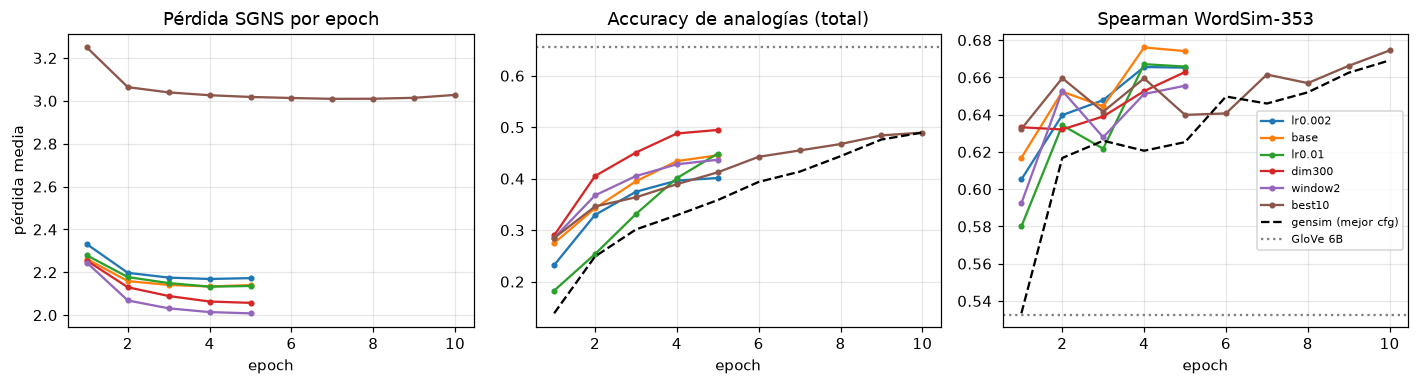

In [22]:
# Curvas de pérdida y de accuracy de analogías por epoch
show = ["sgns_lr0.002", "sgns_base", "sgns_lr0.01", "sgns_dim300", "sgns_window2", BEST_NAME]
show = list(dict.fromkeys(show))
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for n in show:
    lg = RUNS[n][1]; ep = [e["epoch"] for e in lg["epochs"]]
    lab = n.replace("sgns_", "")
    ax[0].plot(ep, [e["loss"] for e in lg["epochs"]], "o-", ms=3, label=lab)
    ax[1].plot(ep, [e["an_total"] for e in lg["epochs"]], "o-", ms=3, label=lab)
    ax[2].plot(ep, [e["wordsim"] for e in lg["epochs"]], "o-", ms=3, label=lab)
ep = [e["epoch"] for e in GENSIM_LOG["epochs"]]
ax[1].plot(ep, [e["an_total"] for e in GENSIM_LOG["epochs"]], "k--", label="gensim (mejor cfg)")
ax[2].plot(ep, [e["wordsim"] for e in GENSIM_LOG["epochs"]], "k--", label="gensim (mejor cfg)")
for a in ax[1:]:
    a.axhline(quick_eval(GLOVE)["an_total"] if a is ax[1] else quick_eval(GLOVE)["wordsim"], c="gray", ls=":", label="GloVe 6B")
ax[0].set(title="Pérdida SGNS por epoch", xlabel="epoch", ylabel="pérdida media")
ax[1].set(title="Accuracy de analogías (total)", xlabel="epoch")
ax[2].set(title="Spearman WordSim-353", xlabel="epoch")
ax[2].legend(fontsize=7)
savefig("curvas_entrenamiento")

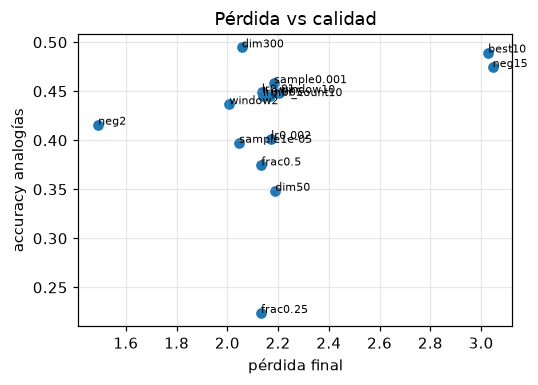

In [23]:
# ¿Menor pérdida => mejores embeddings? Pérdida final vs accuracy en todas las iteraciones
fig, ax = plt.subplots(figsize=(5, 3.6))
ax.scatter(iters["loss"], iters["an_total"])
for _, r in iters.iterrows():
    ax.annotate(r["run"].replace("sgns_", ""), (r["loss"], r["an_total"]), fontsize=7)
ax.set(xlabel="pérdida final", ylabel="accuracy analogías", title="Pérdida vs calidad")
savefig("loss_vs_acc")

In [24]:
# Vecinos más cercanos de las palabras de control por epoch (mejor SGNS)
for e in SGNS_LOG["epochs"]:
    print(f"epoch {e['epoch']}:", {w: [x for x, _ in v] for w, v in e["neighbors"].items()})

epoch 1: {'king': ['uncrowned', 'oswine', 'angoulême', 'ingild', 'wenceslaus'], 'france': ['italy', 'spain', 'alsace', 'austria', 'belgium'], 'computer': ['pdp-1', 'computers', 'desktop', 'minicomputer', 'sgi'], 'good': ['repetitious', 'decent', 'darn', 'outrageously', 'garden-variety'], 'january': ['february', 'march', 'december', 'july', 'june'], 'run': ['running', 'walk-off', 'inside-the-park', '75-yard', '2-run']}
epoch 2: {'king': ['bagler', 'helmichis', 'uncrowned', 'wenceslaus', 'osric'], 'france': ['spain', 'portugal', 'belgium', 'italy', 'alsace'], 'computer': ['desktop', 'pen-and-paper', 'computers', 'software', 'spacewar'], 'good': ['riddance', 'crummy', 'terrific', 'underhanded', 'decent'], 'january': ['february', 'june', 'july', 'november', 'december'], 'run': ['inside-the-park', '2-run', 'extra-inning', 'ninth-inning', 'walk-off']}
epoch 3: {'king': ['ragnaill', 'uncrowned', 'wenceslaus', 'osric', 'ingild'], 'france': ['spain', 'italy', 'portugal', 'anglo-spanish', 'austr

In [25]:
# Guardar el mejor modelo en formato word2vec (.txt) y KeyedVectors (.kv)
kv_best = SGNS.to_kv()
kv_best.save_word2vec_format(str(MODELS / "sgns_best_vectors.txt"), binary=False)
kv_best.save(str(MODELS / "sgns_best_vectors.kv"))
print("guardado", MODELS / "sgns_best_vectors.txt")

guardado /home/anthony/Repositorios/Lab7-DL/models/sgns_best_vectors.txt


## 5. Verificación de la aritmética vectorial
Modelos: mejor SGNS propio, Word2Vec de gensim (misma configuración) y GloVe 100d.
### 5.1 Analogías individuales
`analogia(a, b, c, k)` resuelve «a es a b como c es a ?» con **3CosAdd**:
$\arg\max_x \cos(x,\, \hat b - \hat a + \hat c)$ sobre vectores normalizados, excluyendo a, b y c. El espacio de
búsqueda son las 100,000 palabras más frecuentes de cada modelo.

In [26]:
MODELS3 = {"SGNS": SGNS, "gensim": GENSIM, "GloVe": GLOVE}
RESTRICT = 100_000

@torch.no_grad()
def analogia(a, b, c, k=5, emb=None, exclude=True, restrict=RESTRICT):
    """«a es a b como c es a ?» -> top-k [(palabra, coseno)] y el vector de cosenos completo."""
    emb = emb if emb is not None else SGNS
    U = emb.unit()[:restrict]
    ia, ib, ic = (emb.stoi[w] for w in (a, b, c))
    target = U[ib] - U[ia] + U[ic]
    sims = U @ target / target.norm()
    if exclude:
        sims[[ia, ib, ic]] = -float("inf")
    v, i = sims.topk(k)
    return [(emb.words[j], float(x)) for x, j in zip(v.tolist(), i.tolist())], sims

# Verificación contra gensim.most_similar(positive=[b, c], negative=[a])
for name, emb in MODELS3.items():
    kv = emb.to_kv() if name != "GloVe" else glove
    for a, b, c in [("man", "king", "woman"), ("france", "paris", "japan"), ("good", "better", "bad")]:
        mine, _ = analogia(a, b, c, 5, emb)
        ref = kv.most_similar(positive=[b, c], negative=[a], topn=5, restrict_vocab=RESTRICT)
        same = [w for w, _ in mine] == [w for w, _ in ref] and np.allclose([s for _, s in mine], [s for _, s in ref], atol=1e-4)
        print(f"{name:6s} {a}:{b} :: {c}:? -> {mine[0][0]:10s} coincide con gensim: {same}")

SGNS   man:king :: woman:? -> jagiellon  coincide con gensim: True
SGNS   france:paris :: japan:? -> tokyo      coincide con gensim: True
SGNS   good:better :: bad:? -> worse      coincide con gensim: True
gensim man:king :: woman:? -> jagiellon  coincide con gensim: True


gensim france:paris :: japan:? -> tokyo      coincide con gensim: True
gensim good:better :: bad:? -> worse      coincide con gensim: True
GloVe  man:king :: woman:? -> queen      coincide con gensim: True
GloVe  france:paris :: japan:? -> tokyo      coincide con gensim: True
GloVe  good:better :: bad:? -> worse      coincide con gensim: True


In [27]:
MIS_ANALOGIAS = [  # (tipo, a, b, c, esperada)
    ("género", "man", "king", "woman", "queen"), ("género", "man", "actor", "woman", "actress"),
    ("género", "boy", "prince", "girl", "princess"), ("género", "father", "son", "mother", "daughter"),
    ("país-capital", "france", "paris", "japan", "tokyo"), ("país-capital", "canada", "ottawa", "australia", "canberra"),
    ("país-capital", "egypt", "cairo", "kenya", "nairobi"),
    ("país-gentilicio", "france", "french", "germany", "german"), ("país-gentilicio", "china", "chinese", "mexico", "mexican"),
    ("país-gentilicio", "italy", "italian", "brazil", "brazilian"),
    ("comparativo/superlativo", "good", "better", "bad", "worse"), ("comparativo/superlativo", "big", "biggest", "small", "smallest"),
    ("comparativo/superlativo", "fast", "faster", "strong", "stronger"),
    ("tiempo verbal", "walk", "walked", "swim", "swam"), ("tiempo verbal", "go", "went", "take", "took"),
    ("tiempo verbal", "run", "running", "eat", "eating"),
    ("plural", "car", "cars", "child", "children"), ("plural", "city", "cities", "country", "countries"),
    ("plural", "mouse", "mice", "foot", "feet"),
    ("antónimo", "possible", "impossible", "legal", "illegal"),
]

rows, rows_noex = [], []
for tipo, a, b, c, d in MIS_ANALOGIAS:
    for name, emb in MODELS3.items():
        if not all(w in emb.stoi and emb.stoi[w] < RESTRICT for w in (a, b, c, d)):
            rows.append(dict(tipo=tipo, analogia=f"{a}:{b}::{c}:{d}", modelo=name, top5="(OOV)", rango=np.nan)); continue
        top, sims = analogia(a, b, c, 5, emb)
        rank = int((sims > sims[emb.stoi[d]]).sum().item()) + 1
        rows.append(dict(tipo=tipo, analogia=f"{a}:{b}::{c}:{d}", modelo=name,
                         top5=", ".join(f"{w} ({s:.2f})" for w, s in top), rango=rank,
                         cos_correcta=float(sims[emb.stoi[d]]), acierto=top[0][0] == d))
        top_ne, _ = analogia(a, b, c, 3, emb, exclude=False)
        first = top_ne[0][0]
        rows_noex.append(dict(analogia=f"{a}:{b}::{c}:{d}", modelo=name, top3_sin_excluir=", ".join(f"{w} ({s:.2f})" for w, s in top_ne),
                              primero=first, es={a: "a", b: "b", c: "c", d: "esperada"}.get(first, "otra")))
ind = pd.DataFrame(rows); ind_noex = pd.DataFrame(rows_noex)
ind.to_csv(RESULTS / "analogias_individuales.csv", index=False)
ind_noex.to_csv(RESULTS / "analogias_sin_exclusion.csv", index=False)
print(ind.groupby("modelo")[["acierto"]].mean(), "\n", ind.pivot(index="analogia", columns="modelo", values="rango"))
ind

        acierto
modelo         
GloVe      0.85
SGNS       0.75
gensim     0.70 
 modelo                              GloVe  SGNS  gensim
analogia                                               
big:biggest::small:smallest            11    11       6
boy:prince::girl:princess               1     1       3
canada:ottawa::australia:canberra       2   250     120
car:cars::child:children                1     1       1
china:chinese::mexico:mexican           1     1       1
city:cities::country:countries          1     1       1
egypt:cairo::kenya:nairobi              1     1       1
fast:faster::strong:stronger            1     1       1
father:son::mother:daughter             1     1       1
france:french::germany:german           1     1       1
france:paris::japan:tokyo               1     1       1
go:went::take:took                      1     1       1
good:better::bad:worse                  1     1       1
italy:italian::brazil:brazilian         1     1       1
man:actor::woman:actre

,tipo,analogia,modelo,top5,rango,cos_correcta,acierto
0,género,man:king::woman:queen,SGNS,"jagiellon (0.74), queen (0.73), guelders (0.68), throne (0.68), consort (0.68)",2,0.730351,False
1,género,man:king::woman:queen,gensim,"jagiellon (0.72), obrenović (0.71), regnant (0.70), eanflæd (0.70), queen (0.69)",5,0.691923,False
2,género,man:king::woman:queen,GloVe,"queen (0.77), monarch (0.68), throne (0.68), daughter (0.66), princess (0.65)",1,0.769854,True
3,género,man:actor::woman:actress,SGNS,"actress (0.86), balan (0.68), actors (0.66), actresses (0.66), singer (0.64)",1,0.855750,True
4,género,man:actor::woman:actress,gensim,"actress (0.83), taymor (0.67), actors (0.67), leandersson (0.66), moonstruck (0.65)",1,0.834807,True
5,género,man:actor::woman:actress,GloVe,"actress (0.91), comedian (0.69), actresses (0.68), screenwriter (0.66), starred (0.65)",1,0.907357,True
6,género,boy:prince::girl:princess,SGNS,"princess (0.67), consort (0.66), queen (0.66), hrh (0.64), saxe-coburg-saalfeld (0.59)",1,0.668102,True
7,género,boy:prince::girl:princess,gensim,"hrh (0.66), queen (0.65), princess (0.65), dodi (0.64), great-grandmother (0.63)",3,0.646170,False
8,género,boy:prince::girl:princess,GloVe,"princess (0.80), queen (0.68), king (0.63), daughter (0.63), duchess (0.63)",1,0.798501,True
9,género,father:son::mother:daughter,SGNS,"daughter (0.87), wife (0.80), eldest (0.79), grandson (0.75), daughters (0.75)",1,0.870623,True


**Sin excluir las palabras de la consulta**: ¿qué aparece en primer lugar?

In [28]:
print(ind_noex.groupby(["modelo", "es"]).size().unstack(fill_value=0))
ind_noex

es      b  c  esperada  otra
modelo                      
GloVe   3  6        10     1
SGNS    4  8         7     1
gensim  4  9         7     0


,analogia,modelo,top3_sin_excluir,primero,es
0,man:king::woman:queen,SGNS,"king (0.77), jagiellon (0.74), queen (0.73)",king,b
1,man:king::woman:queen,gensim,"king (0.78), jagiellon (0.72), obrenović (0.71)",king,b
2,man:king::woman:queen,GloVe,"king (0.84), queen (0.77), monarch (0.68)",king,b
3,man:actor::woman:actress,SGNS,"actress (0.86), actor (0.79), balan (0.68)",actress,esperada
4,man:actor::woman:actress,gensim,"actress (0.83), actor (0.79), taymor (0.67)",actress,esperada
5,man:actor::woman:actress,GloVe,"actress (0.91), actor (0.86), comedian (0.69)",actress,esperada
6,boy:prince::girl:princess,SGNS,"prince (0.83), princess (0.67), consort (0.66)",prince,b
7,boy:prince::girl:princess,gensim,"prince (0.81), hrh (0.66), queen (0.65)",prince,b
8,boy:prince::girl:princess,GloVe,"prince (0.92), princess (0.80), queen (0.68)",prince,b
9,father:son::mother:daughter,SGNS,"daughter (0.87), mother (0.87), son (0.86)",daughter,esperada


### 5.2 Evaluación sistemática (vocabulario compartido)
Vocabulario compartido: las 30,000 palabras más frecuentes (según nuestro corpus) que están en los tres modelos.
Las mismas preguntas se evalúan para los tres. Se reporta cobertura y accuracy por categoría con 3CosAdd y
3CosMul.

In [29]:
SHARED = [w for w in SGNS.words if w in GENSIM.stoi and w in GLOVE.stoi][:30_000]
print("vocabulario compartido:", len(SHARED), "| última palabra:", SHARED[-1])
SYS = {}
for name, emb in MODELS3.items():
    for method in ("add", "mul"):
        SYS[(name, method)] = analogy_eval(emb, cand_words=SHARED, method=method)

rows = []
for cat in list(AN_CATS) + ["SEMÁNTICAS", "SINTÁCTICAS", "TOTAL"]:
    r = dict(categoria=cat)
    for (name, method), res in SYS.items():
        if cat in AN_CATS:
            pc = res["per_cat"][cat]; acc = pc["correct"] / max(pc["n"], 1); cov = pc["n"] / pc["total"]
        else:
            k = {"SEMÁNTICAS": "sem", "SINTÁCTICAS": "syn", "TOTAL": "total"}[cat]; acc = res[k]["acc"]; cov = res[k]["coverage"]
        r[f"{name}_{method}"] = acc
        r["cobertura"] = cov
    rows.append(r)
cat_tbl = pd.DataFrame(rows)
cat_tbl.to_csv(RESULTS / "analogias_por_categoria.csv", index=False)
cat_tbl.round(3)

vocabulario compartido: 30000 | última palabra: jumper


,categoria,SGNS_add,cobertura,SGNS_mul,gensim_add,gensim_mul,GloVe_add,GloVe_mul
0,capital-common-countries,0.708,0.751,0.668,0.729,0.668,0.929,0.911
1,capital-world,0.571,0.231,0.523,0.579,0.521,0.883,0.859
2,currency,0.019,0.062,0.019,0.019,0.019,0.056,0.056
3,city-in-state,0.361,0.709,0.326,0.324,0.299,0.302,0.268
4,family,0.564,0.676,0.503,0.576,0.529,0.880,0.868
5,gram1-adjective-to-adverb,0.121,0.819,0.105,0.132,0.113,0.280,0.278
6,gram2-opposite,0.070,0.335,0.062,0.143,0.103,0.272,0.239
7,gram3-comparative,0.517,1.000,0.503,0.578,0.552,0.800,0.781
8,gram4-superlative,0.325,0.626,0.313,0.298,0.295,0.608,0.611
9,gram5-present-participle,0.438,0.824,0.386,0.430,0.386,0.722,0.716


### 5.3 Paralelismo de los vectores diferencia
Si la aritmética fuera exacta, todos los vectores diferencia de una relación (p.ej. $\hat{paris}-\hat{france}$,
$\hat{tokyo}-\hat{japan}$, …) serían paralelos (coseno 1). Medimos el **coseno promedio entre todos los pares de
vectores diferencia** de cada categoría y lo comparamos con una línea base de pares mal emparejados (se barajan
los segundos elementos).

In [30]:
def category_pairs(cat, vocab_set):
    ps = set()
    for a, b, c, d in AN_CATS[cat]:
        ps.add((a, b)); ps.add((c, d))
    return sorted(p for p in ps if p[0] in vocab_set and p[1] in vocab_set)

@torch.no_grad()
def mean_pairwise_cos(emb, pairs):
    U = emb.unit()
    D = U[[emb.stoi[b] for _, b in pairs]] - U[[emb.stoi[a] for a, _ in pairs]]
    D = F.normalize(D, dim=1); S = D @ D.T
    n = len(pairs)
    return float((S.sum() - n) / (n * (n - 1))) if n >= 2 else float("nan")

shared_set = set(SHARED)
rng = np.random.default_rng(SEED)
rows = []
for cat in AN_CATS:
    pairs = category_pairs(cat, shared_set)
    shuffled = list(zip([a for a, _ in pairs], rng.permutation([b for _, b in pairs])))
    shuffled = [(a, b) for a, b in shuffled if a != b]
    r = dict(categoria=cat, n_pares=len(pairs))
    for name, emb in MODELS3.items():
        r[name] = mean_pairwise_cos(emb, pairs)
        r[f"{name}_base"] = mean_pairwise_cos(emb, shuffled)
    rows.append(r)
par_tbl = pd.DataFrame(rows)
par_avg = par_tbl[[c for c in par_tbl.columns if c not in ("categoria", "n_pares")]].mean()
par_tbl.to_csv(RESULTS / "paralelismo.csv", index=False)
print("promedio (macro) por modelo:\n", par_avg.round(3))
par_tbl.round(3)

promedio (macro) por modelo:
 SGNS           0.238
SGNS_base      0.116
gensim         0.241
gensim_base    0.118
GloVe          0.404
GloVe_base     0.175
dtype: float64


,categoria,n_pares,SGNS,SGNS_base,gensim,gensim_base,GloVe,GloVe_base
0,capital-common-countries,20,0.338,0.163,0.348,0.164,0.582,0.256
1,capital-world,56,0.247,0.123,0.259,0.126,0.567,0.245
2,currency,8,0.276,0.211,0.245,0.201,0.251,0.207
3,city-in-state,57,0.182,0.116,0.187,0.120,0.337,0.242
4,family,19,0.250,0.116,0.254,0.116,0.507,0.198
5,gram1-adjective-to-adverb,29,0.118,0.059,0.125,0.064,0.271,0.128
6,gram2-opposite,17,0.088,0.042,0.102,0.047,0.231,0.101
7,gram3-comparative,37,0.296,0.154,0.311,0.162,0.424,0.170
8,gram4-superlative,27,0.277,0.176,0.283,0.177,0.465,0.265
9,gram5-present-participle,30,0.158,0.043,0.179,0.053,0.319,0.076


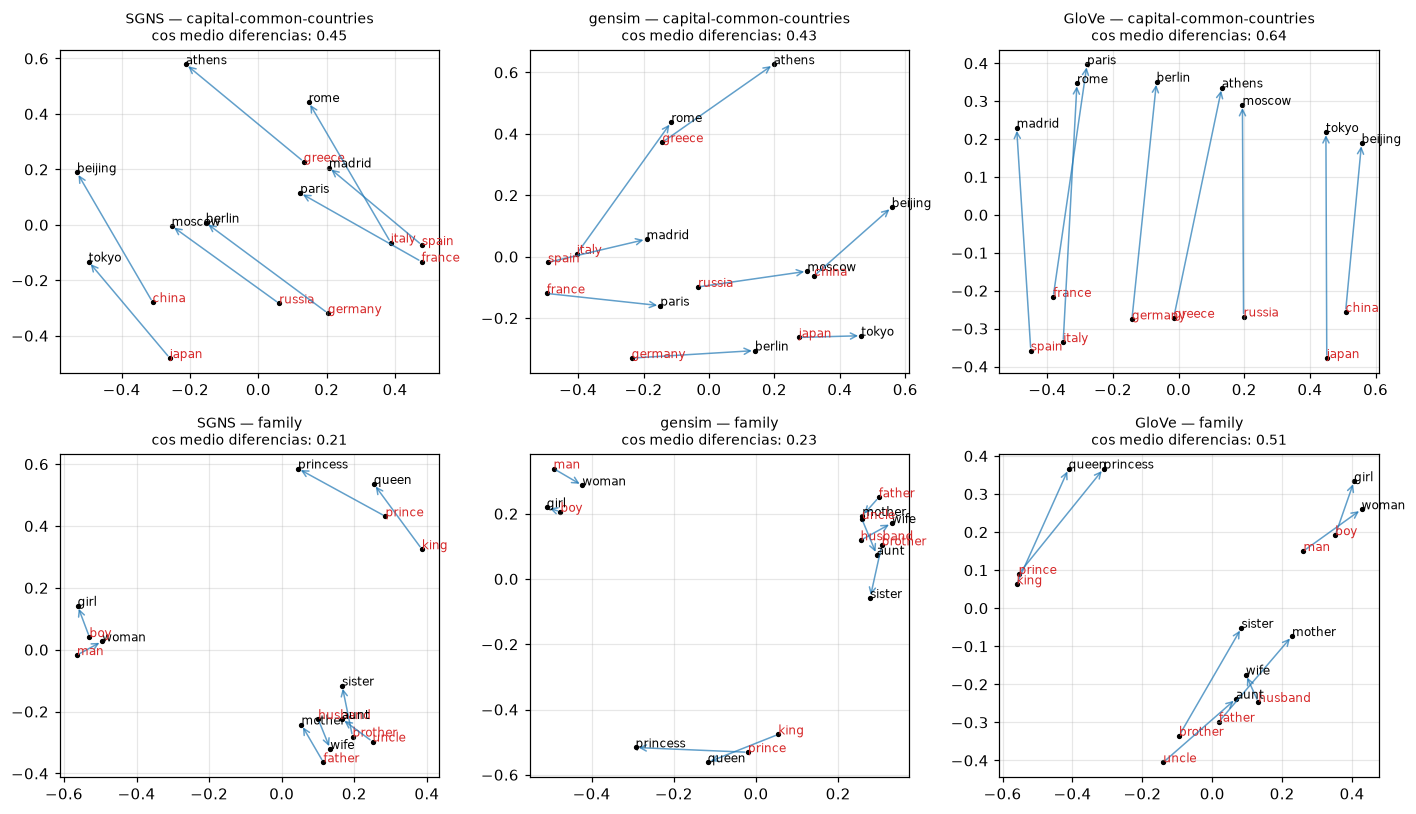

In [31]:
# Visualización de paralelismo: PCA 2D de pares país-capital y masculino-femenino
from sklearn.decomposition import PCA
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
sets = [("capital-common-countries", [("greece", "athens"), ("japan", "tokyo"), ("france", "paris"), ("russia", "moscow"),
                                      ("china", "beijing"), ("italy", "rome"), ("spain", "madrid"), ("germany", "berlin")]),
        ("family", [("man", "woman"), ("king", "queen"), ("boy", "girl"), ("father", "mother"), ("brother", "sister"),
                    ("husband", "wife"), ("uncle", "aunt"), ("prince", "princess")])]
for row, (title, pairs) in enumerate(sets):
    for col, (name, emb) in enumerate(MODELS3.items()):
        ws = [w for p in pairs for w in p]
        X = emb.unit()[[emb.stoi[w] for w in ws]].cpu().numpy()
        P = PCA(2, random_state=SEED).fit_transform(X)
        ax = axes[row, col]
        for i in range(0, len(ws), 2):
            ax.annotate("", P[i + 1], P[i], arrowprops=dict(arrowstyle="->", color="C0", alpha=0.7))
            ax.text(*P[i], ws[i], fontsize=8, color="C3"); ax.text(*P[i + 1], ws[i + 1], fontsize=8)
        ax.scatter(P[:, 0], P[:, 1], s=6, c="k")
        ax.set_title(f"{name} — {title}\ncos medio diferencias: {mean_pairwise_cos(emb, pairs):.2f}", fontsize=9)
savefig("paralelismo_pca")

### 5.4 t-SNE de ~500 palabras en grupos temáticos (mejor SGNS vs GloVe)

palabras para t-SNE: 479 Counter({'países': 60, 'capitales': 57, 'ciudades EE.UU.': 56, 'animales': 54, 'verbos': 46, 'números': 31, 'profesiones': 30, 'comida': 28, 'cuerpo': 26, 'elementos': 20, 'colores': 19, 'meses/días': 19, 'deportes': 19, 'instrumentos': 14})


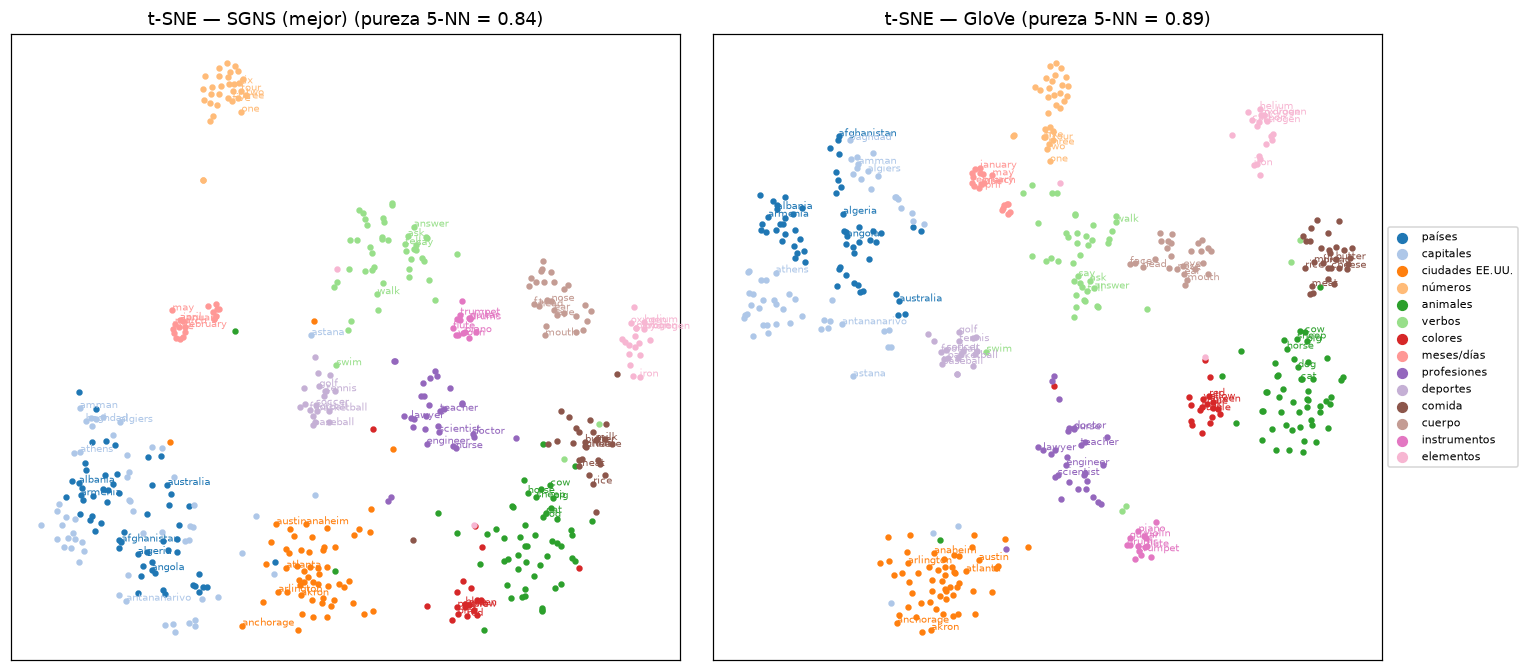

{'SGNS': 0.8438413361169103, 'gensim': 0.8450939457202505, 'GloVe': 0.8918580375782881}


In [32]:
GROUPS = {
    "países": sorted({b for a, b, c, d in AN_CATS["capital-world"]}),
    "capitales": sorted({a for a, b, c, d in AN_CATS["capital-world"]}),
    "ciudades EE.UU.": sorted({a for a, b, c, d in AN_CATS["city-in-state"]}),
    "números": "one two three four five six seven eight nine ten eleven twelve thirteen fourteen fifteen sixteen seventeen eighteen nineteen twenty thirty forty fifty sixty seventy eighty ninety hundred thousand million billion".split(),
    "animales": "dog cat horse cow pig sheep goat chicken duck goose wolf fox bear lion tiger leopard elephant giraffe zebra monkey gorilla rabbit rat squirrel deer moose bison buffalo camel donkey snake lizard frog turtle crocodile shark whale dolphin seal otter beaver eagle hawk owl crow sparrow parrot penguin swan bee ant spider butterfly salmon trout".split(),
    "verbos": "say tell ask answer walk swim fly drive ride eat drink sleep write read sing dance build destroy create buy sell give bring carry throw catch push pull open close begin finish stop win lose kill attack defend teach learn think believe know understand remember forget".split(),
    "colores": "red blue green yellow purple pink brown black white gray grey violet crimson scarlet turquoise maroon navy silver golden".split(),
    "meses/días": "january february march april may june july august september october november december monday tuesday wednesday thursday friday saturday sunday".split(),
    "profesiones": "doctor lawyer teacher engineer nurse scientist professor architect journalist painter musician singer actor writer poet farmer soldier pilot sailor priest judge banker accountant chef baker carpenter plumber mechanic surgeon dentist photographer".split(),
    "deportes": "football soccer basketball baseball tennis golf hockey cricket rugby volleyball boxing wrestling swimming cycling skiing athletics badminton rowing fencing".split(),
    "comida": "bread rice meat cheese butter milk egg apple banana grape lemon potato tomato onion garlic beef pork sugar salt pepper wine beer coffee tea soup cake chocolate honey".split(),
    "cuerpo": "head face eye ear nose mouth tooth tongue neck shoulder arm elbow hand finger leg knee foot toe heart lung liver brain stomach skin bone blood".split(),
    "instrumentos": "guitar piano violin drums trumpet flute saxophone cello bass harp clarinet organ trombone accordion banjo".split(),
    "elementos": "hydrogen helium oxygen nitrogen carbon iron copper gold zinc lead tin sodium potassium calcium magnesium aluminium uranium mercury sulfur chlorine".split(),
}
seen, tsne_words, tsne_groups = set(), [], []
for g, ws in GROUPS.items():
    ws = [w for w in ws if w in shared_set and w not in seen][:60]
    seen.update(ws); tsne_words += ws; tsne_groups += [g] * len(ws)
print("palabras para t-SNE:", len(tsne_words), collections.Counter(tsne_groups))

from sklearn.manifold import TSNE
def knn_purity(emb, words, groups, k=5):
    X = emb.unit()[[emb.stoi[w] for w in words]]
    S = X @ X.T; S.fill_diagonal_(-2)
    nn_idx = S.topk(k, dim=1).indices.cpu().numpy()
    g = np.array(groups)
    return float((g[nn_idx] == g[:, None]).mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
cmap = plt.get_cmap("tab20")
for ax, (name, emb) in zip(axes, [("SGNS (mejor)", SGNS), ("GloVe", GLOVE)]):
    X = emb.unit()[[emb.stoi[w] for w in tsne_words]].cpu().numpy()
    Y = TSNE(2, perplexity=30, metric="cosine", init="pca", random_state=SEED).fit_transform(X)
    for gi, g in enumerate(GROUPS):
        m = np.array(tsne_groups) == g
        ax.scatter(Y[m, 0], Y[m, 1], s=10, color=cmap(gi), label=g)
        for j in np.where(m)[0][:6]:
            ax.text(Y[j, 0], Y[j, 1], tsne_words[j], fontsize=6.5, color=cmap(gi))
    ax.set_title(f"t-SNE — {name} (pureza 5-NN = {knn_purity(emb, tsne_words, tsne_groups):.2f})")
    ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(fontsize=7, markerscale=2, loc="center left", bbox_to_anchor=(1, 0.5))
savefig("tsne")
TSNE_PURITY = {n: knn_purity(e, tsne_words, tsne_groups) for n, e in MODELS3.items()}
print(TSNE_PURITY)

## 6. Pipeline end-to-end: clasificación de AG News
texto → `tokenize` (el mismo de la sección 2) → IDs → `nn.EmbeddingBag(mean)` → MLP → 4 clases.
10 % del train como validación (estratificado); el test oficial sólo se usa al final.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

CLASSES = news["train"].features["label"].names
ag_tok = [tokenize(t) for t in news["train"]["text"]]
ag_y = np.array(news["train"]["label"])
te_tok = [tokenize(t) for t in news["test"]["text"]]
te_y = np.array(news["test"]["label"])
tr_idx, va_idx = train_test_split(np.arange(len(ag_y)), test_size=0.1, stratify=ag_y, random_state=SEED)
print("train", len(tr_idx), "val", len(va_idx), "test", len(te_y), "| clases:", CLASSES)
print("ejemplo:", news["train"]["text"][0], "\n->", ag_tok[0])

train 108000 val 12000 test 7600 | clases: ['World', 'Sports', 'Business', 'Sci/Tech']
ejemplo: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. 
-> ['wall', 'st.', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short-sellers', 'wall', 'street', "'s", 'dwindling', 'band', 'of', 'ultra-cynics', 'are', 'seeing', 'green', 'again']


In [34]:
# Porcentaje de tokens de AG News fuera del vocabulario de cada conjunto de embeddings
def oov_rate(docs, vocab_set):
    tot = sum(len(d) for d in docs); oov = sum(1 for d in docs for w in d if w not in vocab_set)
    return oov / tot
OOV = {name: dict(train=oov_rate([ag_tok[i] for i in tr_idx], emb.stoi), test=oov_rate(te_tok, emb.stoi))
       for name, emb in MODELS3.items()}
pd.DataFrame(OOV).T.mul(100).round(2)

,train,test
SGNS,3.38,3.34
gensim,3.38,3.34
GloVe,0.83,0.80


In [35]:
def metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return dict(acc=accuracy_score(y_true, y_pred), precision=p, recall=r, f1=f)

# Baseline: TF-IDF (uni+bigramas) + regresión logística; C elegido en validación
def tfidf_fit(train_ids, C):
    vec = TfidfVectorizer(analyzer=lambda d: d + [a + " " + b for a, b in zip(d, d[1:])], min_df=2, sublinear_tf=True)
    X = vec.fit_transform([ag_tok[i] for i in train_ids])
    clf = LogisticRegression(C=C, max_iter=2000).fit(X, ag_y[train_ids])
    return vec, clf

CLF = {}
t0 = time.time()
best_tfidf = None
for C in (1.0, 4.0, 16.0):
    vec, clf = tfidf_fit(tr_idx, C)
    m = metrics(ag_y[va_idx], clf.predict(vec.transform([ag_tok[i] for i in va_idx])))
    print(f"TF-IDF C={C}: val {m}")
    if best_tfidf is None or m["f1"] > best_tfidf[2]["f1"]:
        best_tfidf = (C, (vec, clf), m)
TFIDF_C, (tf_vec, tf_clf), tf_val = best_tfidf
n_params = tf_clf.coef_.size + tf_clf.intercept_.size
CLF["TF-IDF + LogReg"] = dict(val=tf_val, params_total=n_params, params_trainable=n_params, time=time.time() - t0,
                             curves=None, init="TF-IDF", variant="-")

TF-IDF C=1.0: val {'acc': 0.9218333333333333, 'precision': 0.9216468166017744, 'recall': 0.9218333333333333, 'f1': 0.9215989857929421}


TF-IDF C=4.0: val {'acc': 0.9248333333333333, 'precision': 0.9246470295885042, 'recall': 0.9248333333333334, 'f1': 0.9246483442856523}


TF-IDF C=16.0: val {'acc': 0.9229166666666667, 'precision': 0.9226989336424885, 'recall': 0.9229166666666666, 'f1': 0.9227394510366964}


In [36]:
class BagClassifier(nn.Module):
    """EmbeddingBag (promedio) + MLP."""
    def __init__(self, vocab_size, dim, n_classes=4, hidden=256, dropout=0.3, pretrained=None, freeze=False):
        super().__init__()
        if pretrained is not None:
            self.emb = nn.EmbeddingBag.from_pretrained(torch.as_tensor(pretrained), freeze=freeze, mode="mean")
        else:
            self.emb = nn.EmbeddingBag(vocab_size, dim, mode="mean")
        self.mlp = nn.Sequential(nn.Linear(dim, hidden), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, n_classes))
    def forward(self, flat, offsets):
        return self.mlp(self.emb(flat, offsets))

def build_vocab(source):
    """Vocabulario del clasificador. Aleatorio: palabras del train con frecuencia >= 2.
    Preentrenado: palabras del modelo que aparecen en AG News (las demás filas nunca se consultarían)."""
    if source is None:
        cnt = collections.Counter(w for i in tr_idx for w in ag_tok[i])
        itos = [w for w, c in cnt.most_common() if c >= 2]
        return itos, None
    words = sorted({w for d in ag_tok + te_tok for w in d if w in source.stoi})
    return words, source.vectors[[source.stoi[w] for w in words]]

def encode_docs(docs, stoi):
    return [torch.tensor([stoi[w] for w in d if w in stoi], dtype=torch.long) for d in docs]

def batches(enc, y, bs, shuffle, rng=None):
    order = rng.permutation(len(enc)) if shuffle else np.arange(len(enc))
    for i in range(0, len(order), bs):
        idx = order[i:i + bs]
        docs = [enc[j] for j in idx]
        offsets = torch.tensor([0] + [len(d) for d in docs[:-1]]).cumsum(0)
        yield torch.cat(docs).to(DEVICE), offsets.to(DEVICE), torch.as_tensor(y[idx]).to(DEVICE)

@torch.no_grad()
def predict(model, enc, bs=2048):
    model.eval(); out = []
    for x, off, _ in batches(enc, np.zeros(len(enc), int), bs, False):
        out.append(model(x, off).float())
    return torch.cat(out)

def train_bag(source, freeze, train_ids, epochs=8, bs=256, lr=2e-3, patience=3, seed=SEED, verbose=True):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    itos, mat = build_vocab(source)
    stoi = {w: i for i, w in enumerate(itos)}
    model = BagClassifier(len(itos), 100, pretrained=mat, freeze=freeze).to(DEVICE)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    Xtr, ytr = encode_docs([ag_tok[i] for i in train_ids], stoi), ag_y[train_ids]
    Xva, yva = encode_docs([ag_tok[i] for i in va_idx], stoi), ag_y[va_idx]
    curves = dict(train_loss=[], val_loss=[], val_f1=[])
    best = (-1, None, None); bad = 0; t0 = time.time()
    for ep in range(epochs):
        model.train(); tot, n = 0.0, 0
        for x, off, yb in batches(Xtr, ytr, bs, True, rng):
            loss = F.cross_entropy(model(x, off), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(yb); n += len(yb)
        logits = predict(model, Xva)
        vl = F.cross_entropy(logits, torch.as_tensor(yva, device=DEVICE)).item()
        m = metrics(yva, logits.argmax(1).cpu().numpy())
        curves["train_loss"].append(tot / n); curves["val_loss"].append(vl); curves["val_f1"].append(m["f1"])
        if verbose:
            print(f"  ep{ep+1}: train_loss={tot/n:.4f} val_loss={vl:.4f} val_f1={m['f1']:.4f}")
        if m["f1"] > best[0]:
            best = (m["f1"], {k: v.detach().clone() for k, v in model.state_dict().items()}, m); bad = 0
        else:
            bad += 1
            if bad >= patience: break
    model.load_state_dict(best[1])
    info = dict(val=best[2], curves=curves, time=time.time() - t0, epochs_run=ep + 1,
                params_total=sum(p.numel() for p in model.parameters()),
                params_trainable=sum(p.numel() for p in model.parameters() if p.requires_grad), vocab=len(itos))
    return model, stoi, info

VARIANTS = [("Aleatorio", None, False)] + [(f"{n} {'congelado' if fz else 'fine-tuning'}", n, fz)
                                            for n in ("SGNS", "gensim", "GloVe") for fz in (True, False)]
BAG = {}
for label, src, fz in VARIANTS:
    print(label)
    model, stoi, info = train_bag(MODELS3[src] if src else None, fz, tr_idx)
    BAG[label] = (model, stoi); CLF[label] = dict(info, init=src or "Aleatorio", variant="congelado" if fz else ("fine-tuning" if src else "entrenado"))

clf_tbl = pd.DataFrame([dict(modelo=k, **v["val"], params_total=v["params_total"], params_entrenables=v["params_trainable"],
                             tiempo_s=v["time"]) for k, v in CLF.items()])
clf_tbl.to_csv(RESULTS / "clasificacion_val.csv", index=False)
clf_tbl.round(4)

Aleatorio


  ep1: train_loss=0.5408 val_loss=0.3251 val_f1=0.8904


  ep2: train_loss=0.2717 val_loss=0.2750 val_f1=0.9107


  ep3: train_loss=0.2057 val_loss=0.2643 val_f1=0.9142


  ep4: train_loss=0.1619 val_loss=0.2738 val_f1=0.9137


...

  ep2: train_loss=0.2114 val_loss=0.2296 val_f1=0.9229


  ep3: train_loss=0.1615 val_loss=0.2390 val_f1=0.9211


  ep4: train_loss=0.1251 val_loss=0.2620 val_f1=0.9188


  ep5: train_loss=0.0977 val_loss=0.2882 val_f1=0.9161


,modelo,acc,precision,recall,f1,params_total,params_entrenables,tiempo_s
0,TF-IDF + LogReg,0.9248,0.9246,0.9248,0.9246,1698048,1698048,151.2180
1,Aleatorio,0.9143,0.9145,0.9143,0.9142,4950084,4950084,5.9968
2,SGNS congelado,0.8856,0.8856,0.8856,0.8854,4566384,26884,4.0768
3,SGNS fine-tuning,0.9188,0.9187,0.9188,0.9186,4566384,4566384,3.7577
4,gensim congelado,0.8868,0.8893,0.8868,0.8867,4566384,26884,3.9159
5,gensim fine-tuning,0.9185,0.9195,0.9185,0.9185,4566384,4566384,4.7035
6,GloVe congelado,0.9036,0.9041,0.9036,0.9036,6628384,26884,4.0680
7,GloVe fine-tuning,0.9229,0.9236,0.9229,0.9229,6628384,6628384,5.6291


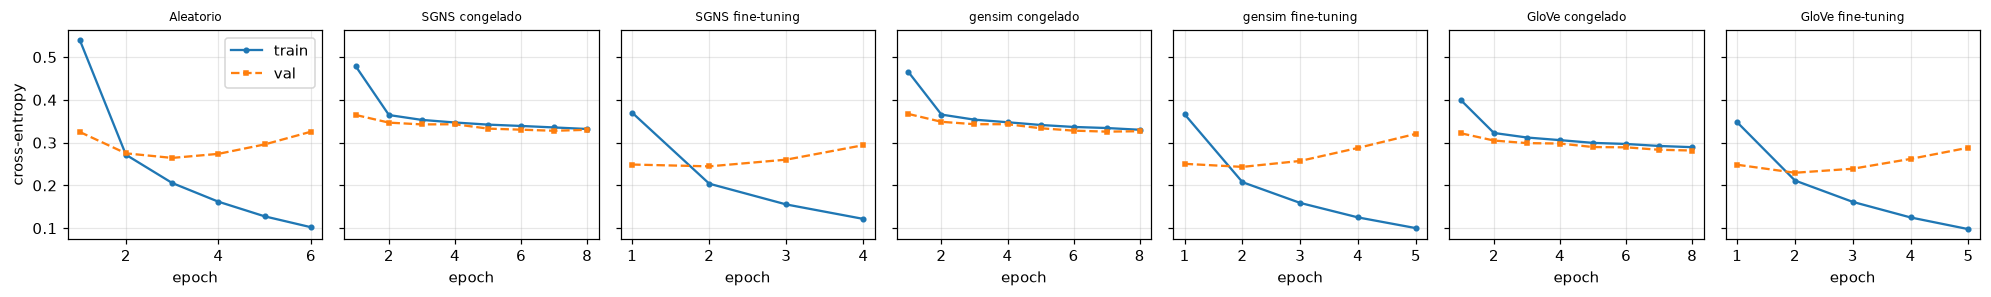

In [37]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(2.6 * len(VARIANTS), 2.8), sharey=True)
for ax, (label, *_ ) in zip(axes, VARIANTS):
    c = CLF[label]["curves"]; ep = range(1, len(c["train_loss"]) + 1)
    ax.plot(ep, c["train_loss"], "o-", ms=3, label="train"); ax.plot(ep, c["val_loss"], "s--", ms=3, label="val")
    ax.set_title(label, fontsize=8); ax.set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy"); axes[0].legend()
savefig("curvas_clasificacion")

### Evaluación final en test (una sola vez por inicialización)
Se elige la mejor variante (congelada vs fine-tuning) de cada inicialización por F1 de validación.

{'TF-IDF': 'TF-IDF + LogReg', 'Aleatorio': 'Aleatorio', 'SGNS': 'SGNS fine-tuning', 'gensim': 'gensim fine-tuning', 'GloVe': 'GloVe fine-tuning'}


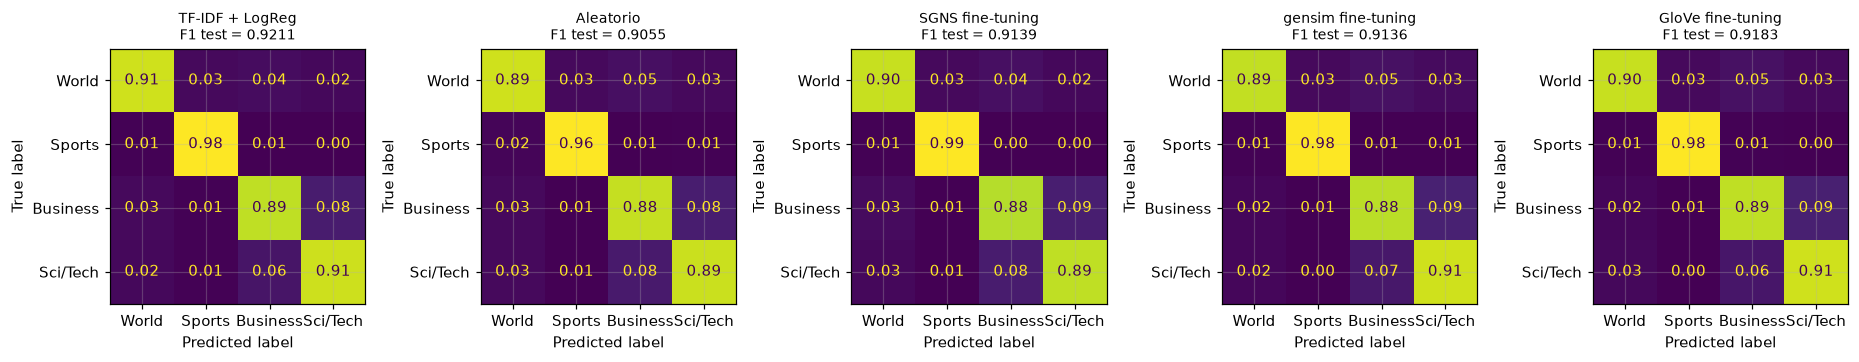

,modelo,acc,precision,recall,f1
TF-IDF,TF-IDF + LogReg,0.921316,0.921176,0.921316,0.921134
Aleatorio,Aleatorio,0.905526,0.905677,0.905526,0.905539
SGNS,SGNS fine-tuning,0.914079,0.91394,0.914079,0.9139
gensim,gensim fine-tuning,0.913553,0.914293,0.913553,0.913576
GloVe,GloVe fine-tuning,0.918289,0.918675,0.918289,0.918275


In [38]:
best_by_init = {"TF-IDF": "TF-IDF + LogReg", "Aleatorio": "Aleatorio"}
for n in ("SGNS", "gensim", "GloVe"):
    best_by_init[n] = max([f"{n} congelado", f"{n} fine-tuning"], key=lambda k: CLF[k]["val"]["f1"])
print(best_by_init)

TEST = {}
fig, axes = plt.subplots(1, 5, figsize=(17, 3.4))
for ax, (init, label) in zip(axes, best_by_init.items()):
    if init == "TF-IDF":
        pred = tf_clf.predict(tf_vec.transform(te_tok))
    else:
        model, stoi = BAG[label]
        pred = predict(model, encode_docs(te_tok, stoi)).argmax(1).cpu().numpy()
    TEST[init] = dict(modelo=label, **metrics(te_y, pred))
    ConfusionMatrixDisplay(confusion_matrix(te_y, pred, normalize="true"), display_labels=CLASSES).plot(
        ax=ax, colorbar=False, values_format=".2f")
    ax.set_title(f"{label}\nF1 test = {TEST[init]['f1']:.4f}", fontsize=9)
savefig("confusion_test")
test_tbl = pd.DataFrame(TEST).T
test_tbl.to_csv(RESULTS / "clasificacion_test.csv")
test_tbl

### SimLex-999 (evaluación final de similitud, reservada hasta ahora)

In [39]:
SIMLEX_RES = {n: similarity_eval(e, SL_PAIRS) for n, e in MODELS3.items()}
SIMLEX_SHARED = {n: similarity_eval(e, SL_PAIRS, vocab_words=shared_set) for n, e in MODELS3.items()}
WS_RES = {n: similarity_eval(e, WS_PAIRS) for n, e in MODELS3.items()}
pd.DataFrame({"SimLex (vocab propio)": {n: r["spearman"] for n, r in SIMLEX_RES.items()},
              "cobertura": {n: r["coverage"] for n, r in SIMLEX_RES.items()},
              "SimLex (vocab compartido)": {n: r["spearman"] for n, r in SIMLEX_SHARED.items()},
              "WordSim-353": {n: r["spearman"] for n, r in WS_RES.items()}}).round(4)

,SimLex (vocab propio),cobertura,SimLex (vocab compartido),WordSim-353
SGNS,0.2946,0.996,0.2894,0.6744
gensim,0.3122,0.996,0.3062,0.6691
GloVe,0.2975,1.000,0.3072,0.5327


### F1 de test contra fracción de datos de entrenamiento
Para cada fracción (muestreo estratificado del 90 % de train) y cada inicialización se entrena el clasificador;
para SGNS/gensim/GloVe se elige congelado vs fine-tuning por F1 de validación (como en el protocolo principal).
En fracciones pequeñas se usan más epochs (máx. $\min(60, 8/\sqrt{p})$) con early stopping y 3 semillas.

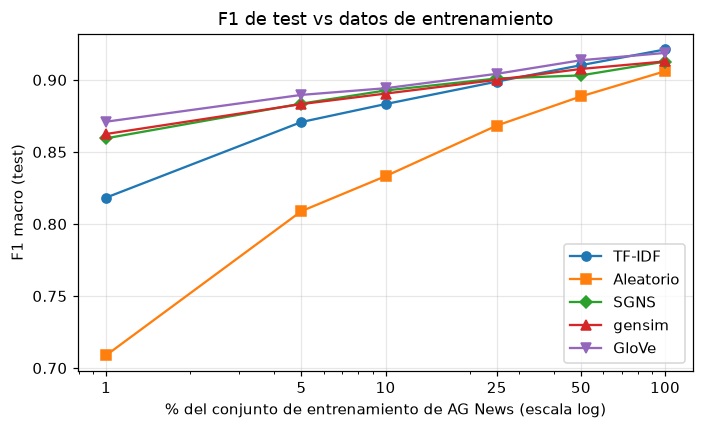

test_f1                                          val_f1  \
frac                     0.01    0.05    0.10    0.25    0.50    1.00    0.01   
init      variant                                                               
Aleatorio fine-tuning  0.7088  0.8089  0.8332  0.8683  0.8886  0.9060  0.7145   
GloVe     congelado    0.8684  0.8805  0.8829  0.8903  0.8925  0.8968  0.8755   
          fine-tuning  0.8710  0.8896  0.8942  0.9042  0.9136  0.9187  0.8758   
SGNS      congelado    0.8542  0.8666  0.8674  0.8798  0.8825  0.8844  0.8592   
          fine-tuning  0.8595  0.8835  0.8927  0.9010  0.9031  0.9127  0.8668   
TF-IDF    -            0.8183  0.8708  0.8832  0.8988  0.9102  0.9211  0.8272   
gensim    congelado    0.8561  0.8653  0.8662  0.8806  0.8833  0.8834  0.8583   
          fine-tuning  0.8624  0.8832  0.8905  0.9001  0.9076  0.9128  0.8647   

                                                               
frac                     0.05    0.10    0.25    0.50    1.00  
init      variant                                              
Aleatorio fine-tuning  0.8191  0.8445  0.8785  0.8955  0.9121  
GloVe     congelado    0.8881  0.8934  0.9008  0.9012  0.9035  
          fine-tuning  0.8953  0.9010  0.9098  0.9161  0.9238  
SGNS      congelado    0.8720  0.8718  0.8827  0.8848  0.8858  
          fine-tuning  0.8885  0.8980  0.9063  0.9090  0.9181  
TF-IDF    -            0.8799  0.8944  0.9061  0.9159  0.9246  
gensim    congelado    0.8683  0.8709  0.8824  0.8859  0.8859  
          fine-tuning  0.8871  0.8953  0.9047  0.9086  0.9185

In [40]:
FRACS = (0.01, 0.05, 0.1, 0.25, 0.5, 1.0)
frac_rows = []
FRAC_CACHE = RESULTS / "fraccion_agnews.csv"
if FRAC_CACHE.exists():
    frac_df = pd.read_csv(FRAC_CACHE)
else:
    for p in FRACS:
        seeds = (0, 1, 2) if p <= 0.05 else (0,)
        for sd in seeds:
            if p < 1:
                sub, _ = train_test_split(tr_idx, train_size=p, stratify=ag_y[tr_idx], random_state=sd)
            else:
                sub = tr_idx
            ep_max = int(min(60, 8 / math.sqrt(p))); bs = 64 if p < 0.1 else 256
            vec, clf = tfidf_fit(sub, TFIDF_C)
            Xte = vec.transform(te_tok)
            frac_rows.append(dict(frac=p, seed=sd, init="TF-IDF", variant="-",
                                  val_f1=metrics(ag_y[va_idx], clf.predict(vec.transform([ag_tok[i] for i in va_idx])))["f1"],
                                  test_f1=metrics(te_y, clf.predict(Xte))["f1"]))
            for label, src, fz in VARIANTS:
                model, stoi, info = train_bag(MODELS3[src] if src else None, fz, sub, epochs=ep_max, bs=bs, seed=sd, verbose=False)
                pred = predict(model, encode_docs(te_tok, stoi)).argmax(1).cpu().numpy()
                frac_rows.append(dict(frac=p, seed=sd, init=src or "Aleatorio", variant="congelado" if fz else "fine-tuning",
                                      val_f1=info["val"]["f1"], test_f1=metrics(te_y, pred)["f1"]))
                del model; torch.cuda.empty_cache()
            print(f"fracción {p} semilla {sd} lista")
    frac_df = pd.DataFrame(frac_rows); frac_df.to_csv(FRAC_CACHE, index=False)

agg = frac_df.groupby(["frac", "init", "variant"])[["val_f1", "test_f1"]].mean().reset_index()
sel = agg.loc[agg.groupby(["frac", "init"])["val_f1"].idxmax()]   # mejor variante por validación
fig, ax = plt.subplots(figsize=(6.5, 4))
for init, mk in zip(["TF-IDF", "Aleatorio", "SGNS", "gensim", "GloVe"], "osD^v"):
    s = sel[sel.init == init].sort_values("frac")
    ax.plot(s.frac * 100, s.test_f1, marker=mk, label=init)
ax.set_xscale("log"); ax.set(xlabel="% del conjunto de entrenamiento de AG News (escala log)", ylabel="F1 macro (test)",
                             title="F1 de test vs datos de entrenamiento")
ax.set_xticks([1, 5, 10, 25, 50, 100]); ax.set_xticklabels(["1", "5", "10", "25", "50", "100"]); ax.legend()
savefig("f1_vs_fraccion")
agg.pivot_table(index=["init", "variant"], columns="frac", values=["val_f1", "test_f1"]).round(4)

## 7. Comparación de resultados

In [41]:
GLOVE_INFO = dict(tokens=6_000_000_000, vocab=400_000,
                  tiempo="≈85 min co-ocurrencias (1 hilo) + 50 iteraciones (≤14 min/iter, 32 núcleos)",
                  hardware="2× Intel Xeon E5-2658 2.1 GHz (Pennington et al., 2014)")
def g(res, k): return res[k]["acc"]
comp = {}
for name, emb in MODELS3.items():
    lg = {"SGNS": SGNS_LOG, "gensim": GENSIM_LOG}.get(name)
    comp[name] = {
        "tokens corpus": lg["corpus_tokens"] if lg else GLOVE_INFO["tokens"],
        "vocabulario": len(emb), "dimensión": emb.dim,
        "tiempo entrenamiento": f"{lg['total_time']/60:.1f} min" if lg else GLOVE_INFO["tiempo"],
        "hardware": (HW["gpu"] if name == "SGNS" else f"CPU {HW['cpu_threads']} hilos") if lg else GLOVE_INFO["hardware"],
        **{f"{k} {m}": g(SYS[(name, m)], k) for m in ("add", "mul") for k in ("sem", "syn", "total")},
        "WordSim-353": WS_RES[name]["spearman"], "SimLex-999": SIMLEX_RES[name]["spearman"],
        "cos medio vect. diferencia": par_avg[name], "OOV AG News (%)": 100 * OOV[name]["test"],
        "F1 test": TEST[name]["f1"],
    }
comp_tbl = pd.DataFrame(comp)
comp_tbl.to_csv(RESULTS / "comparacion.csv")
comp_tbl

,SGNS,gensim,GloVe
tokens corpus,30000534,30000534,6000000000
vocabulario,109700,109700,400000
dimensión,100,100,100
tiempo entrenamiento,46.2 min,16.8 min,"≈85 min co-ocurrencias (1 hilo) + 50 iteraciones (≤14 min/iter, 32 núcleos)"
hardware,NVIDIA GeForce RTX 3070 Laptop GPU,CPU 8 hilos,"2× Intel Xeon E5-2658 2.1 GHz (Pennington et al., 2014)"
sem add,0.473684,0.461366,0.590426
syn add,0.496308,0.500424,0.682847
total add,0.489479,0.488633,0.654948
sem mul,0.432531,0.421053,0.56355
syn mul,0.472945,0.468587,0.669653


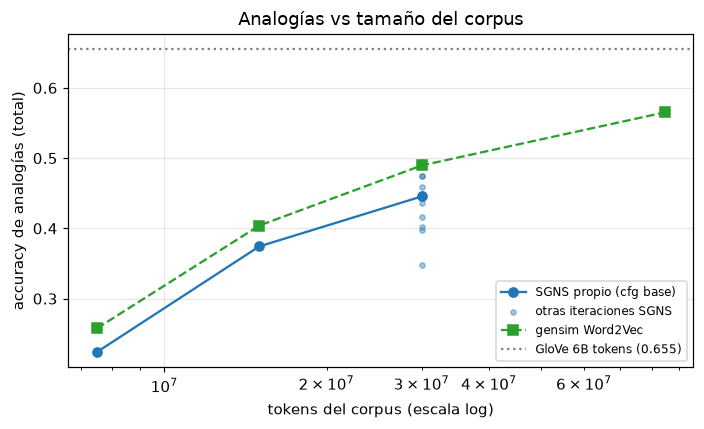

In [42]:
# (1) Accuracy de analogías vs tokens del corpus (protocolo de la sección 4: top-30k de cada modelo)
glove_acc = quick_eval(GLOVE)["an_total"]
fig, ax = plt.subplots(figsize=(6.5, 4))
pts = [(RUNS[n][1]["corpus_tokens"], RUNS[n][1]["epochs"][-1]["an_total"]) for n in ("sgns_frac0.25", "sgns_frac0.5", "sgns_base")]
ax.plot(*zip(*pts), "o-", label="SGNS propio (cfg base)")
ax.scatter([RUNS[n][1]["corpus_tokens"] for n in RUNS if n.startswith("sgns_")],
           [RUNS[n][1]["epochs"][-1]["an_total"] for n in RUNS if n.startswith("sgns_")], s=12, c="C0", alpha=0.4,
           label="otras iteraciones SGNS")
gp = sorted((l["corpus_tokens"], l["epochs"][-1]["an_total"]) for n, (_, l) in G_RUNS.items() if n != "gensim_best")
gp = sorted(set(gp + [(GENSIM_LOG["corpus_tokens"], GENSIM_LOG["epochs"][-1]["an_total"])]))
ax.plot(*zip(*gp), "s--", c="C2", label="gensim Word2Vec")
ax.axhline(glove_acc, c="gray", ls=":", label=f"GloVe 6B tokens ({glove_acc:.3f})")
ax.set_xscale("log"); ax.set(xlabel="tokens del corpus (escala log)", ylabel="accuracy de analogías (total)",
                             title="Analogías vs tamaño del corpus"); ax.legend(fontsize=8)
savefig("acc_vs_tokens")

save_json(dict(best_name=BEST_NAME, best_cfg=BEST_CFG, best_lr=best_lr, glove_quick=quick_eval(GLOVE),
               sgns_quick=quick_eval(SGNS), gensim_quick=quick_eval(GENSIM), oov=OOV, test=TEST, simlex=SIMLEX_RES,
               simlex_shared=SIMLEX_SHARED, wordsim=WS_RES, par_avg=par_avg.to_dict(), tsne_purity=TSNE_PURITY,
               tfidf_C=TFIDF_C, best_by_init=best_by_init, shared_last=SHARED[-1],
               clf={k: {kk: vv for kk, vv in v.items() if kk != "curves"} for k, v in CLF.items()},
               gensim_runs={n: dict(tokens=l["corpus_tokens"], an_total=l["epochs"][-1]["an_total"],
                                    wordsim=l["epochs"][-1]["wordsim"], time=l["total_time"]) for n, (_, l) in G_RUNS.items()}),
          "sec5_7.json")

## 8. Discusión y análisis
(La versión completa, con todas las cifras, está en el informe PDF `informe/informe.pdf`.)

- **Aritmética vectorial.** Se cumple *aproximadamente*: el mejor SGNS resuelve 49 % de `questions-words.txt` (vocabulario
  compartido) y 15/20 analogías propias. Funciona mejor en gentilicios (86 %), países-capitales comunes (71 %) y pasado (63 %);
  falla en monedas (2 %), opuestos (7 %) y adjetivo→adverbio (12 %). Semánticas 47 % vs sintácticas 50 %.
- **¿«≈» es igualdad?** No: sin excluir la consulta, `b` o `c` ganan en 12/20 analogías (SGNS; `king` antes que `queen` en los
  tres modelos), el coseno con la respuesta correcta es 0.7–0.8 y los vectores diferencia de una relación tienen coseno medio
  0.24 (GloVe 0.40), lejos de 1.
- **Distancia a GloVe (−16.6 puntos).** Con el mismo método, gensim pasa de 25.8 % (7.5 M) → 40.4 % (15 M) → 49.0 % (30 M) →
  56.5 % (85 M): sólo pasar a 85 M cierra el 45 % de la brecha; GloVe usa 70× más tokens. El resto: dimensión (d=300: +5),
  ventana/iteraciones de GloVe y su vocabulario de 400 k.
- **SGNS propio vs gensim.** Prácticamente iguales (48.95 % vs 48.96 %, WordSim 0.674 vs 0.669, F1 AG News 0.914 vs 0.914).
  Diferencias: SparseAdam con batches grandes (converge antes por epoch) vs SGD asíncrono con lr lineal.
- **Hiperparámetros.** d: 50→100→300 = 34.9→44.5→49.5 %. Ventana 2→5→10: sintácticas 48.3→47.1→46.1 %, semánticas
  32.8→38.7→41.8 % (ventanas pequeñas favorecen lo sintáctico). Negativos 2→5→15: 41.6→44.5→47.5 %. Menor pérdida ≠ mejores
  embeddings (K=2 tiene la menor pérdida y peores analogías).
- **AG News.** Fine-tuning de preentrenados > aleatorio (0.914–0.918 vs 0.906 F1 test), pero TF-IDF+bigramas gana con todos
  los datos (0.921). Con todos los datos conviene fine-tuning (congelar cuesta 3–4 puntos); con 1 % de los datos los
  preentrenados superan al aleatorio por 15–16 puntos y a TF-IDF por 4–5, y congelar ≈ fine-tuning.